In [ ]:
! pip install apimoex
import apimoex

In [ ]:
! pip install apimoex requests pandas
! pip install yfinance pandas matplotlib

In [32]:
import pandas_datareader as pdr
import requests
import pandas as pd
from datetime import datetime, timedelta
import time
from typing import List, Dict
import os
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import yfinance as yf
import numpy as np
import matplotlib.dates as mdates
import scipy.stats as stats
from scipy.stats import shapiro, kstest, jarque_bera
from statsmodels.tsa.stattools import adfuller


# Parsing stock quotes from MOEX

Stock trading occurs over several sessions. Therefore, it's important to download stock quotes that include all trades.

You can connect via the `iss_url` link, which provides data for all trades. In the `start_date` and `end_date` parameters, specify the required download dates (including both the start and end dates). In `tickers`, enter the stock tickers from the Moscow Exchange website.

In [ ]:
import requests
import pandas as pd

# List of stock tickers
tickers = ["LKOH", "GAZP", "SBER", "LENT", "GMKN"]

# Base URL of the MOEX ISS API
iss_url = "https://iss.moex.com/iss/history/engines/stock/markets/shares/boards/tqbr/securities/"

# Time period for data collection
start_date = "2024-01-01"
end_date = "2026-02-27"

# Pagination parameter:
# the API returns data in portions ("pages"), so we request it step by step
batch_size = 100  # Maximum number of records returned per API request

# Container for storing downloaded quote data
data = []

# Function to retrieve stock quotes with pagination
def get_stock_quotes(ticker):
    # 'start' defines the starting position for pagination:
    # for example, start = 0 means "give me the first batch_size records starting from row 0"
    start = 0

    while True:
        url = f"{iss_url}{ticker}.json?from={start_date}&till={end_date}&start={start}"
        response = requests.get(url)

        # Check whether the request was successful
        if response.status_code != 200:
            print(f"Error retrieving data for {ticker}: {response.status_code}")
            break

        json_data = response.json()

        try:
            quotes = json_data["history"]["data"]

            # Stop the loop if no more data is available
            if not quotes:
                break

            for quote in quotes:
                record = {
                    # Creating a record using selected fields
                    # Python uses zero-based indexing:
                    # TRADEDATE   -> trading date   (2nd column in parsed data)
                    # SECID       -> security ID    (4th column in parsed data)
                    # LEGALCLOSEPRICE    -> number of trades (10th column in parsed data)
                    "TRADEDATE": quote[1],
                    "SECID": quote[3],
                    "LEGALCLOSEPRICE": quote[10],
                }
                data.append(record)

            # 'history.cursor' contains pagination metadata
            cursor = json_data["history.cursor"]

            # Check whether we have reached the end of available data
            if cursor["data"][0][0] >= cursor["data"][0][1]:
                break

            # Move to the next page
            start = cursor["data"][0][0] + batch_size

        except KeyError as e:
            print(f"Error processing data for {ticker}: {e}")
            break

# Download data for each ticker
for ticker in tickers:
    get_stock_quotes(ticker)

# Create a DataFrame and reshape it into a pivot table
if data:
    d1 = pd.DataFrame(data)

    filtered_df = d1.pivot_table(
        index="TRADEDATE",
        columns="SECID",
        values="LEGALCLOSEPRICE",
        fill_value=0
    )

    # Sort dates in descending order
    filtered_df = filtered_df.sort_index(ascending=False)

    # Preserve the original ticker order
    filtered_df = filtered_df[tickers]

    print(filtered_df.head())
else:
    print("No data was retrieved.")

SECID         LKOH    GAZP    SBER    LENT    GMKN
TRADEDATE                                         
2026-02-27  5191.5  127.04  314.63  2106.0  164.32
2026-02-26  5153.0  127.10  317.11  2049.5  161.32
2026-02-25  5169.0  126.94  316.60  2055.5  159.12
2026-02-24  5207.5  127.52  315.78  2058.5  156.70
2026-02-20  5184.5  125.80  313.58  2058.0  153.92


In [ ]:
# Convert the collected data into a DataFrame
d1 = pd.DataFrame(data)

# Create a pivot table:
# rows   → trading dates
# columns → stock tickers (SECID)
# values → number of trades (NUMTRADES)
# fill_value=0 ensures missing values are replaced with zeros
filtered_df = d1.pivot_table(
    index='TRADEDATE',
    columns='SECID',
    values='LEGALCLOSEPRICE',  # alternatively: LEGALCLOSEPRICE for closing prices
    fill_value=0
)

# Sort the DataFrame by date in descending order (most recent first)
filtered_df = filtered_df.sort_index(ascending=False)

# Reorder columns to match the original ticker list
filtered_df = filtered_df[tickers]

# Display the first 5 rows
filtered_df.head(5)

# Example reference (MOEX data source):
# https://www.moex.com/ru/marketdata/#/mode=instrument&secid=GMKN&boardgroupid=57&mode_type=history&date_from=2024-01-02&date_till=2024-02-29

SECID,LKOH,GAZP,SBER,LENT,GMKN
TRADEDATE,,,,,
2026-02-27,5191.5,127.04,314.63,2106.0,164.32
2026-02-26,5153.0,127.10,317.11,2049.5,161.32
2026-02-25,5169.0,126.94,316.60,2055.5,159.12
2026-02-24,5207.5,127.52,315.78,2058.5,156.70
2026-02-20,5184.5,125.80,313.58,2058.0,153.92


In [ ]:
filtered_df.to_excel('original_prices.xlsx')

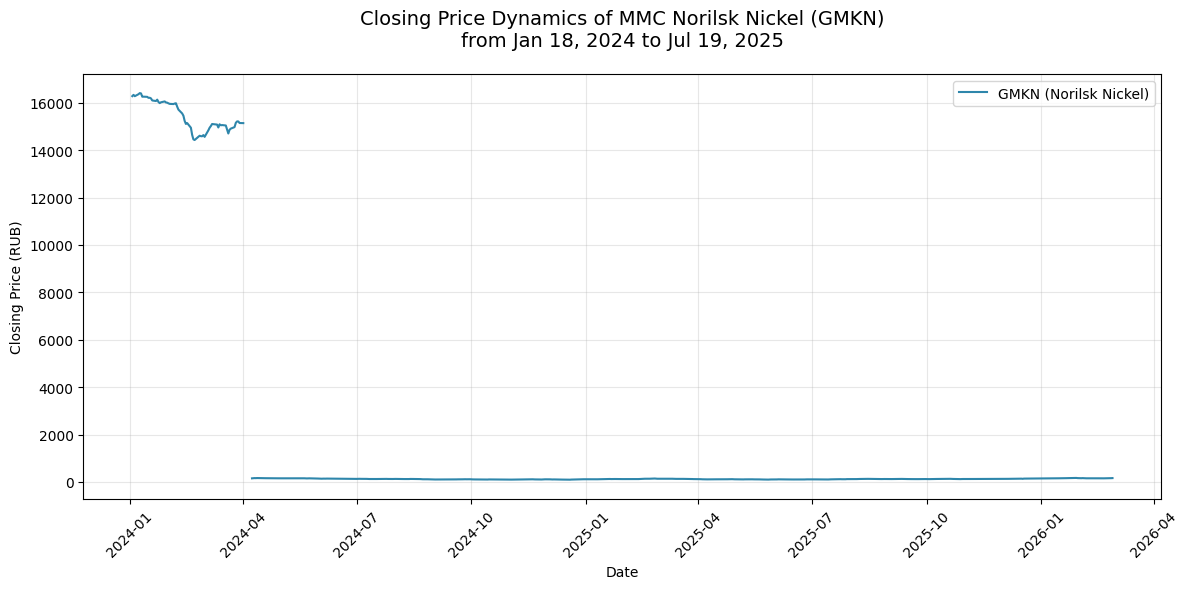

In [ ]:
# Filter the dataset for GMKN (Norilsk Nickel)
gmkn_data = d1[d1['SECID'] == 'GMKN'].copy()

# Convert trading dates to datetime format
gmkn_data['TRADEDATE'] = pd.to_datetime(gmkn_data['TRADEDATE'])

# Sort the data in chronological order
gmkn_data.sort_values('TRADEDATE', inplace=True)

# Plot the closing price time series
plt.figure(figsize=(12, 6))

plt.plot(
    gmkn_data['TRADEDATE'],
    gmkn_data['LEGALCLOSEPRICE'],
    label='GMKN (Norilsk Nickel)',
    color='#2E86AB'
)

# Add title and axis labels
plt.title(
    'Closing Price Dynamics of MMC Norilsk Nickel (GMKN)\n'
    'from Jan 18, 2024 to Jul 19, 2025',
    fontsize=14,
    pad=20
)

plt.xlabel('Date')
plt.ylabel('Closing Price (RUB)')

# Add legend and grid
plt.legend()
plt.grid(True, alpha=0.3)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Adjust layout to prevent overlap
plt.tight_layout()

# Display the plot
plt.show()

In [ ]:
# Comparing GMKN prices at the beginning and at the end of the dataset
# reveals a structural break (different price scale)

print(filtered_df.head(5))
print(filtered_df.tail(5))

# April 4, 2024 → stock split of Norilsk Nickel (GMKN)

SECID         LKOH    GAZP    SBER    LENT    GMKN
TRADEDATE                                         
2026-02-27  5191.5  127.04  314.63  2106.0  164.32
2026-02-26  5153.0  127.10  317.11  2049.5  161.32
2026-02-25  5169.0  126.94  316.60  2055.5  159.12
2026-02-24  5207.5  127.52  315.78  2058.5  156.70
2026-02-20  5184.5  125.80  313.58  2058.0  153.92
SECID         LKOH    GAZP    SBER   LENT     GMKN
TRADEDATE                                         
2024-01-09  6864.0  162.30  275.70  700.0  16406.0
2024-01-08  6782.5  162.81  275.70  703.0  16360.0
2024-01-05  6781.0  161.72  273.46  687.0  16276.0
2024-01-04  6784.0  161.23  274.37  688.5  16332.0
2024-01-03  6778.5  161.06  273.55  678.5  16278.0


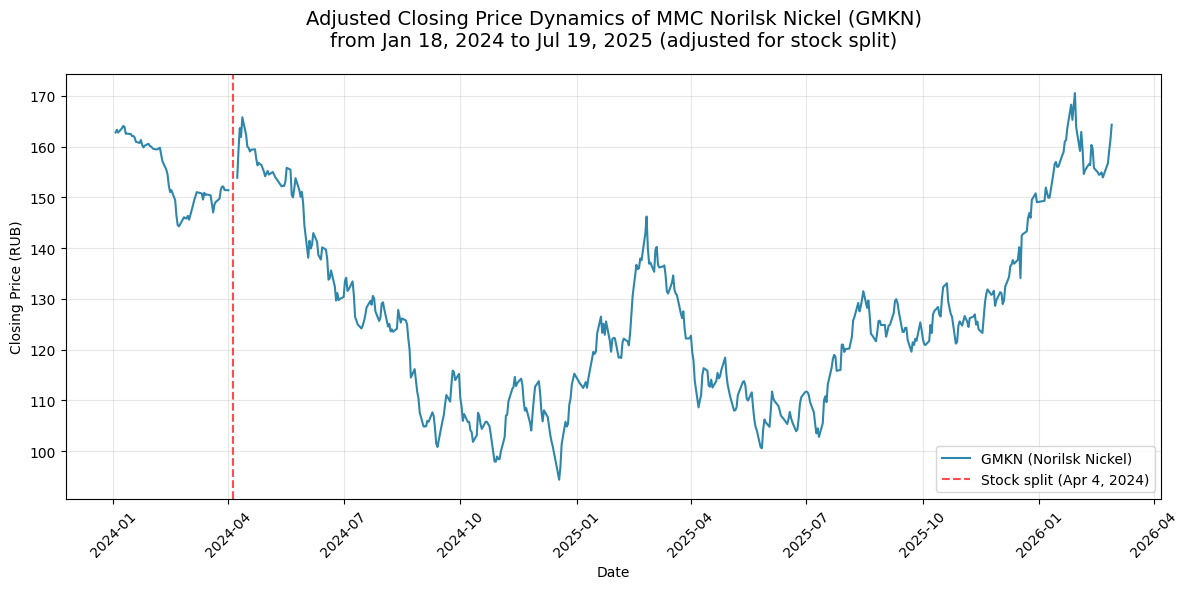

In [ ]:
# Filter the dataset for GMKN (Norilsk Nickel)
gmkn_data = d1[d1['SECID'] == 'GMKN'].copy()

# Convert trading dates to datetime format
gmkn_data['TRADEDATE'] = pd.to_datetime(gmkn_data['TRADEDATE'])

# Sort data in chronological order
gmkn_data.sort_values('TRADEDATE', inplace=True)

# Adjust prices for the stock split:
# divide prices before April 5, 2024 by 100 to ensure comparability
split_date = pd.to_datetime('2024-04-05')

gmkn_data.loc[
    gmkn_data['TRADEDATE'] <= split_date,
    'LEGALCLOSEPRICE'
] = gmkn_data.loc[
    gmkn_data['TRADEDATE'] <= split_date,
    'LEGALCLOSEPRICE'
] / 100

# Plot the adjusted closing price time series
plt.figure(figsize=(12, 6))

plt.plot(
    gmkn_data['TRADEDATE'],
    gmkn_data['LEGALCLOSEPRICE'],
    label='GMKN (Norilsk Nickel)',
    color='#2E86AB'
)

# Add title and axis labels
plt.title(
    'Adjusted Closing Price Dynamics of MMC Norilsk Nickel (GMKN)\n'
    'from Jan 18, 2024 to Jul 19, 2025 (adjusted for stock split)',
    fontsize=14,
    pad=20
)

plt.xlabel('Date')
plt.ylabel('Closing Price (RUB)')

# Add vertical line to indicate the stock split date
plt.axvline(
    x=split_date,
    color='red',
    linestyle='--',
    alpha=0.7,
    label='Stock split (Apr 4, 2024)'
)

# Add legend and grid
plt.legend()
plt.grid(True, alpha=0.3)

# Improve readability of x-axis labels
plt.xticks(rotation=45)

# Adjust layout
plt.tight_layout()

# Display the plot
plt.show()

In [ ]:
# Сохранение в Excel
filtered_df.to_excel('котировки_акций.xlsx', sheet_name='Цены закрытия')

## Parsing lot size
The lot size represents the minimum number of shares that can be traded in a single transaction.

*   If LOTSIZE = 10, trades can be executed in multiples of 10 shares (10, 20, 30, etc.)
*   If LOTSIZE = 1, any number of shares can be traded starting from 1

In [ ]:
import requests
import pandas as pd

# URL to retrieve stock data for the TQBR trading board (MOEX main market)
url = 'https://iss.moex.com/iss/engines/stock/markets/shares/boards/TQBR/securities.json'

# Request parameters:
# disable metadata and select only relevant fields
params = {
    'iss.meta': 'off',
    'securities.columns': 'SECID,LOTSIZE,SHORTNAME'
}

# Send request to the MOEX ISS API
response = requests.get(url, params=params)

# Parse JSON response
data = response.json()

# Convert the data into a pandas DataFrame
securities_data = pd.DataFrame(
    data['securities']['data'],
    columns=data['securities']['columns']
)

# Display selected columns: ticker, company name, and lot size
print(securities_data[['SECID', 'SHORTNAME', 'LOTSIZE']])

     SECID   SHORTNAME  LOTSIZE
0     ABIO  iАРТГЕН ао       10
1     ABRD  АбрауДюрсо       10
2     AFKS  Система ао      100
3     AFLT    Аэрофлот       10
4     AKRN       Акрон        1
..     ...         ...      ...
255   YRSB     ТНСэнЯр       10
256  YRSBP   ТНСэнЯр-п       10
257   ZAYM   Займер ао       10
258   ZILL      ЗИЛ ао        1
259   ZVEZ   ЗВЕЗДА ао     1000

[260 rows x 3 columns]


# Parsing of dividends

In [ ]:
import requests
import pandas as pd

# List of stock tickers
tickers = ["LKOH", "GAZP", "SBER", "LENT", "GMKN"]

# Base URL for MOEX ISS API historical quotes
iss_url = "https://iss.moex.com/iss/history/engines/stock/markets/shares/boards/tqbr/securities/"

# Data collection period
start_date = "2024-01-01"
end_date = "2026-02-27"

# Pagination step
batch_size = 100


def get_stock_quotes(ticker: str, start_date: str, end_date: str, batch_size: int = 100) -> list[dict]:
    """
    Download historical stock quotes for one ticker using pagination.
    """
    records = []
    start = 0

    while True:
        url = f"{iss_url}{ticker}.json?from={start_date}&till={end_date}&start={start}"
        response = requests.get(url, timeout=30)

        if response.status_code != 200:
            print(f"Error retrieving quotes for {ticker}: {response.status_code}")
            break

        json_data = response.json()
        quotes = json_data.get("history", {}).get("data", [])

        if not quotes:
            break

        for quote in quotes:
            records.append({
                "TRADEDATE": quote[1],
                "SECID": quote[3],
                "LEGALCLOSEPRICE": quote[10],
            })

        cursor_data = json_data.get("history.cursor", {}).get("data", [])
        if not cursor_data:
            break

        current_position = cursor_data[0][0]
        total_records = cursor_data[0][1]

        if current_position >= total_records:
            break

        start = current_position + batch_size

    return records


def get_dividends(ticker: str, start_date: str, end_date: str) -> pd.DataFrame:
    """
    Download dividend data for one ticker.
    Returns a DataFrame with columns:
    - date
    - {ticker}_div
    """
    url = f"https://iss.moex.com/iss/securities/{ticker}/dividends.json?iss.meta=off"
    response = requests.get(url, timeout=30)

    if response.status_code != 200:
        print(f"Error retrieving dividends for {ticker}: {response.status_code}")
        return pd.DataFrame(columns=["date", f"{ticker}_div"])

    json_data = response.json()
    dividends_block = json_data.get("dividends", {})
    columns = dividends_block.get("columns", [])
    data = dividends_block.get("data", [])

    if not data:
        return pd.DataFrame(columns=["date", f"{ticker}_div"])

    df = pd.DataFrame(data=data, columns=columns)

    if "registryclosedate" not in df.columns or "value" not in df.columns:
        print(f"Required dividend columns not found for {ticker}")
        return pd.DataFrame(columns=["date", f"{ticker}_div"])

    df = df[["registryclosedate", "value"]].copy()
    df["registryclosedate"] = pd.to_datetime(df["registryclosedate"], errors="coerce")
    df["value"] = pd.to_numeric(df["value"], errors="coerce")

    df = df[
        (df["registryclosedate"] >= pd.to_datetime(start_date)) &
        (df["registryclosedate"] <= pd.to_datetime(end_date))
    ].dropna()

    df = df.rename(columns={
        "registryclosedate": "date",
        "value": f"{ticker}_div"
    })

    return df


# Step 1: Download all stock quotes
all_quotes = []

for ticker in tickers:
    all_quotes.extend(get_stock_quotes(ticker, start_date, end_date, batch_size))


if all_quotes:
    quotes_df = pd.DataFrame(all_quotes)

    # Create pivot table for stock prices
    prices_wide = quotes_df.pivot_table(
        index="TRADEDATE",
        columns="SECID",
        values="LEGALCLOSEPRICE",
        fill_value=0
    )

    prices_wide.index = pd.to_datetime(prices_wide.index)
    prices_wide = prices_wide.sort_index(ascending=False)

    # Rename price columns: LKOH -> LKOH_price
    prices_wide.columns = [f"{col}_price" for col in prices_wide.columns]

    # Step 2: Download and merge dividends
    final_df = prices_wide.copy()

    for ticker in tickers:
        dividends_df = get_dividends(ticker, start_date, end_date)

        if not dividends_df.empty:
            dividends_df = dividends_df.set_index("date")
            final_df = final_df.join(dividends_df, how="outer")

    # Sort final table by date descending
    final_df = final_df.sort_index(ascending=False)

    print("Final table with prices and dividends:")
    print(final_df.head(20))

else:
    print("No quote data was retrieved.")

Final table with prices and dividends:
            GAZP_price  GMKN_price  LENT_price  LKOH_price  SBER_price  \
2026-02-27      127.04      164.32      2106.0      5191.5      314.63   
2026-02-26      127.10      161.32      2049.5      5153.0      317.11   
2026-02-25      126.94      159.12      2055.5      5169.0      316.60   
2026-02-24      127.52      156.70      2058.5      5207.5      315.78   
2026-02-20      125.80      153.92      2058.0      5184.5      313.58   
2026-02-19      126.03      154.92      2085.0      5182.5      313.47   
2026-02-18      126.05      154.58      2094.0      5185.0      312.53   
2026-02-17      126.57      154.44      2127.0      5251.0      310.36   
2026-02-16      127.23      154.94      2123.5      5246.0      311.00   
2026-02-13      126.38      155.78      2092.0      5248.5      306.78   
2026-02-12      125.30      159.52      2113.0      5216.5      306.01   
2026-02-11      124.71      160.34      2085.0      5180.0      304.93   

## Dividend-Adjusted Return Calculation
After a dividend payment, a dividend gap occurs: the stock price typically drops by approximately the amount of the dividend.

To account for this effect, dividends can be incorporated into return calculations by adding the dividend value to prices after the ex-dividend (registry) date.

Important: this adjustment should only be used for calculating returns, not for modifying absolute price levels.

The adjusted metric reflects the total return of the stock, including both price changes and dividend payments.

Original prices:
SECID         LKOH   TATN    MTSS    SBER
TRADEDATE                                
2025-01-03  7125.0  666.4  205.30  273.20
2025-01-06  7108.0  664.6  204.20  272.44
2025-01-08  7110.0  656.0  207.65  276.98
2025-01-09  6994.5  635.4  203.70  271.80
2025-01-10  7030.0  654.2  212.00  278.17

Adjusted prices:
SECID         LKOH    TATN    MTSS    SBER
TRADEDATE                                 
2025-01-03  7125.0  666.40  205.30  273.20
2025-01-06  7108.0  664.60  204.20  272.44
2025-01-08  7110.0  656.00  207.65  276.98
2025-01-09  6994.5  652.79  203.70  271.80
2025-01-10  7030.0  671.59  212.00  278.17

Return comparison for LKOH:
                 Date  Actual Return  Adjusted Return  Difference
TRADEDATE                                                        
2025-07-07 2025-07-07      -0.141895        -0.065965     0.07593
2025-07-08 2025-07-08      -0.149895        -0.073965     0.07593
2025-07-09 2025-07-09      -0.170035        -0.094105     0.07593
2025-07-10 

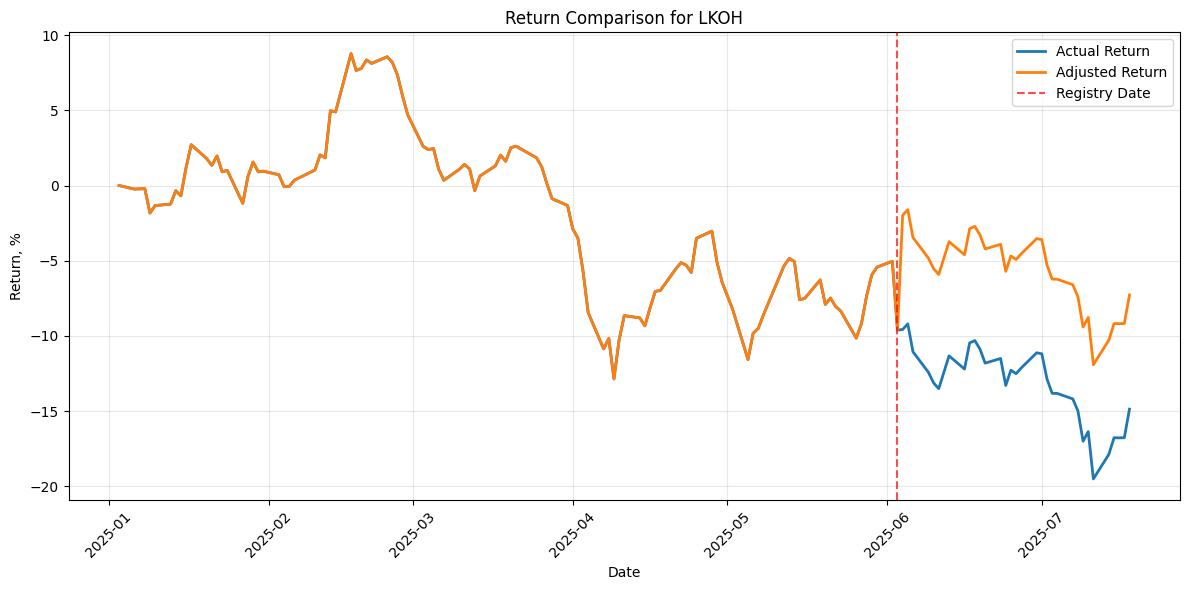


Return comparison for TATN:
                 Date  Actual Return  Adjusted Return  Difference
TRADEDATE                                                        
2025-07-07 2025-07-07      -0.044868         0.045918    0.090786
2025-07-08 2025-07-08      -0.062725         0.028061    0.090786
2025-07-09 2025-07-09      -0.082083         0.008703    0.090786
2025-07-10 2025-07-10      -0.061074         0.029712    0.090786
2025-07-11 2025-07-11      -0.091086        -0.000300    0.090786
2025-07-14 2025-07-14      -0.056273         0.034514    0.090786
2025-07-15 2025-07-15      -0.056723         0.034064    0.090786
2025-07-16 2025-07-16      -0.053571         0.037215    0.090786
2025-07-17 2025-07-17      -0.047119         0.043667    0.090786
2025-07-18 2025-07-18      -0.019958         0.070828    0.090786


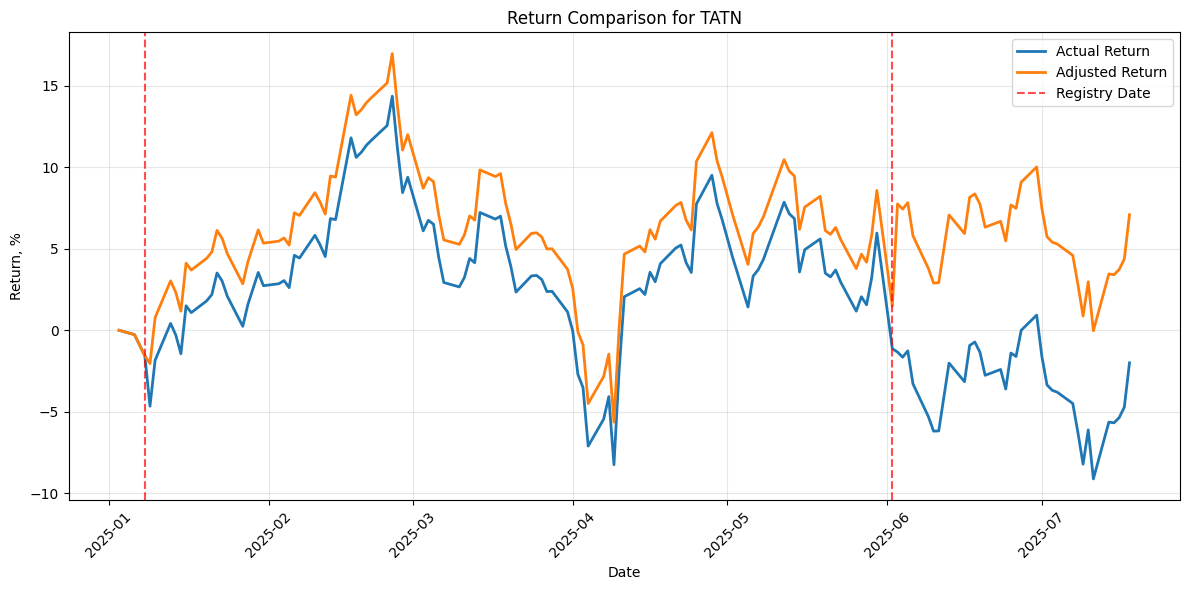


Return comparison for MTSS:
                 Date  Actual Return  Adjusted Return  Difference
TRADEDATE                                                        
2025-07-08 2025-07-08      -0.033366         0.137116    0.170482
2025-07-09 2025-07-09      -0.054798         0.115684    0.170482
2025-07-10 2025-07-10      -0.036775         0.133707    0.170482
2025-07-11 2025-07-11      -0.057720         0.112762    0.170482
2025-07-14 2025-07-14      -0.061617         0.108865    0.170482
2025-07-15 2025-07-15      -0.021919         0.148563    0.170482
2025-07-16 2025-07-16      -0.002923         0.167560    0.170482
2025-07-17 2025-07-17      -0.011934         0.158548    0.170482
2025-07-18 2025-07-18       0.014856         0.185339    0.170482


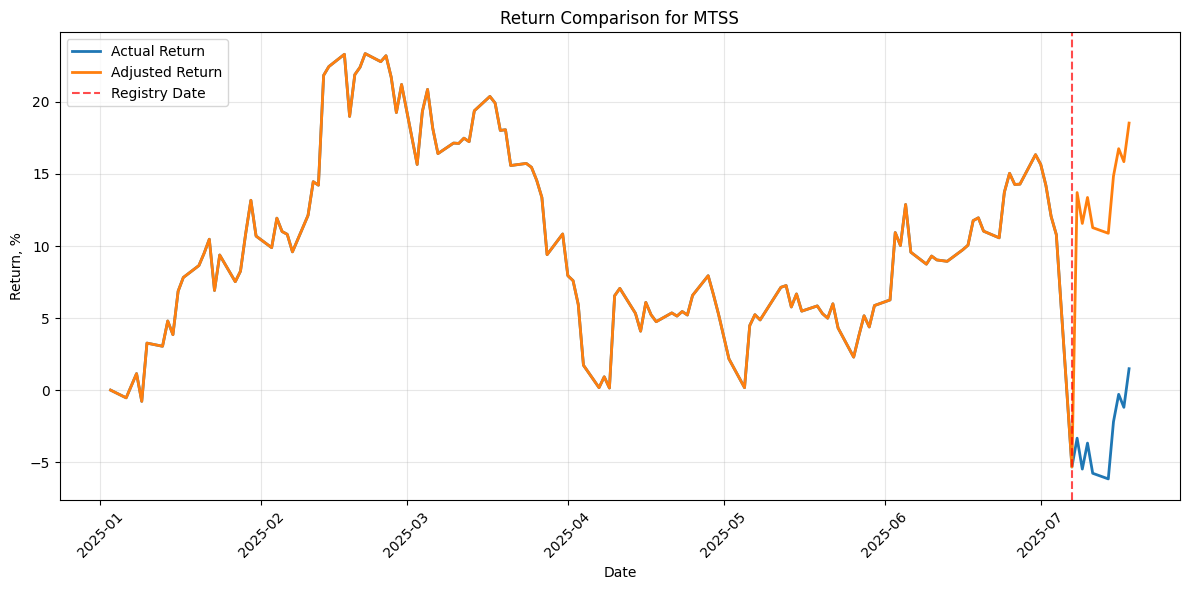


Final returns for the full period:
  Ticker  Actual Return for Period  Adjusted Return for Period  Difference
0   LKOH                 -0.148702                   -0.072772    0.075930
1   TATN                 -0.019958                    0.070828    0.090786
2   MTSS                  0.014856                    0.185339    0.170482
3   SBER                  0.127855                    0.127855    0.000000


In [ ]:
# Analysis period
start_date = "2025-01-01"
end_date = "2025-07-19"

# List of tickers
tickers = ["LKOH", "TATN", "MTSS", "SBER"]

# Base URL for MOEX ISS API historical data
iss_url = "https://iss.moex.com/iss/history/engines/stock/markets/shares/boards/tqbr/securities/"

# Pagination step
batch_size = 100


# ==========================================================
# 1. Download dividends in a unified format
# ==========================================================

def get_dividends_for_ticker(ticker: str) -> pd.DataFrame:
    """
    Download dividends for one ticker and return them
    in a standardized format:
    SECID | Registry_Date | Dividend
    """
    url = f"https://iss.moex.com/iss/securities/{ticker}/dividends.json?iss.meta=off"
    response = requests.get(url, timeout=30)

    if response.status_code != 200:
        print(f"Error retrieving dividends for {ticker}: {response.status_code}")
        return pd.DataFrame(columns=["SECID", "Registry_Date", "Dividend"])

    json_data = response.json()
    dividends_block = json_data.get("dividends", {})
    columns = dividends_block.get("columns", [])
    data = dividends_block.get("data", [])

    if not data:
        return pd.DataFrame(columns=["SECID", "Registry_Date", "Dividend"])

    df = pd.DataFrame(data=data, columns=columns)

    required_columns = {"registryclosedate", "value"}
    if not required_columns.issubset(df.columns):
        print(f"Required dividend columns are missing for {ticker}")
        return pd.DataFrame(columns=["SECID", "Registry_Date", "Dividend"])

    df = df[["registryclosedate", "value"]].copy()
    df["SECID"] = ticker
    df = df.rename(columns={
        "registryclosedate": "Registry_Date",
        "value": "Dividend"
    })

    return df[["SECID", "Registry_Date", "Dividend"]]


# Download dividends for all tickers
dividends_list = [get_dividends_for_ticker(ticker) for ticker in tickers]
dividends_df = pd.concat(dividends_list, ignore_index=True)

# Filter dividends for the selected period
start_dt = pd.to_datetime(start_date)
end_dt = pd.to_datetime(end_date)

dividends_df["Registry_Date_dt"] = pd.to_datetime(
    dividends_df["Registry_Date"],
    errors="coerce"
)

dividends_df["Dividend"] = pd.to_numeric(dividends_df["Dividend"], errors="coerce")

dividends_df = dividends_df[
    (dividends_df["Registry_Date_dt"] >= start_dt) &
    (dividends_df["Registry_Date_dt"] <= end_dt)
].copy()


# ==========================================================
# 2. Download stock quotes with pagination
# ==========================================================

quote_data = []


def get_stock_quotes(ticker: str) -> None:
    """
    Download historical quotes for one ticker using MOEX ISS API pagination.
    """
    start = 0

    while True:
        url = f"{iss_url}{ticker}.json?from={start_date}&till={end_date}&start={start}"
        response = requests.get(url, timeout=30)

        if response.status_code != 200:
            print(f"Error retrieving data for {ticker}: {response.status_code}")
            break

        json_data = response.json()

        try:
            quotes = json_data["history"]["data"]

            if not quotes:
                break

            for quote in quotes:
                quote_data.append({
                    "TRADEDATE": quote[1],
                    "SECID": quote[3],
                    "LEGALCLOSEPRICE": quote[9]
                })

            cursor = json_data["history.cursor"]

            if cursor["data"][0][0] >= cursor["data"][0][1]:
                break

            start = cursor["data"][0][0] + batch_size

        except KeyError as e:
            print(f"Error processing data for {ticker}: {e}")
            break


for ticker in tickers:
    get_stock_quotes(ticker)

if quote_data:
    quotes_df = pd.DataFrame(quote_data)
    quotes_df["TRADEDATE"] = pd.to_datetime(quotes_df["TRADEDATE"])
    quotes_df["LEGALCLOSEPRICE"] = pd.to_numeric(quotes_df["LEGALCLOSEPRICE"], errors="coerce")
    quotes_df = quotes_df.sort_values("TRADEDATE")
    original_quotes = quotes_df.copy()
else:
    print("No quote data was retrieved.")
    quotes_df = pd.DataFrame()


# ==========================================================
# 3. Adjust prices for dividends
# ==========================================================

def adjust_prices(quotes_df: pd.DataFrame, dividends_df: pd.DataFrame) -> pd.DataFrame:
    """
    Adjust historical prices by adding dividends to all dates after the registry date.
    """
    adjusted_quotes = quotes_df.copy()

    for _, dividend_row in dividends_df.iterrows():
        ticker = dividend_row["SECID"]
        registry_date = dividend_row["Registry_Date_dt"]
        dividend_value = dividend_row["Dividend"]

        if pd.isna(registry_date) or pd.isna(dividend_value):
            continue

        mask = (
            (adjusted_quotes["SECID"] == ticker) &
            (adjusted_quotes["TRADEDATE"] > registry_date)
        )

        adjusted_quotes.loc[mask, "LEGALCLOSEPRICE"] = (
            adjusted_quotes.loc[mask, "LEGALCLOSEPRICE"] + dividend_value
        )

    return adjusted_quotes


# ==========================================================
# 4. Calculate returns and compare original vs adjusted
# ==========================================================

if not quotes_df.empty and not dividends_df.empty:
    adjusted_quotes = adjust_prices(quotes_df, dividends_df)

    pivot_original = original_quotes.pivot_table(
        index="TRADEDATE",
        columns="SECID",
        values="LEGALCLOSEPRICE",
        fill_value=np.nan
    )

    pivot_adjusted = adjusted_quotes.pivot_table(
        index="TRADEDATE",
        columns="SECID",
        values="LEGALCLOSEPRICE",
        fill_value=np.nan
    )

    for ticker in tickers:
        if ticker not in pivot_original.columns:
            pivot_original[ticker] = np.nan
        if ticker not in pivot_adjusted.columns:
            pivot_adjusted[ticker] = np.nan

    pivot_original = pivot_original[tickers]
    pivot_adjusted = pivot_adjusted[tickers]

    pivot_original = pivot_original.dropna()
    pivot_adjusted = pivot_adjusted.dropna()

    pivot_original = pivot_original.sort_index(ascending=True)
    pivot_adjusted = pivot_adjusted.sort_index(ascending=True)

    print("Original prices:")
    print(pivot_original.head())

    print("\nAdjusted prices:")
    print(pivot_adjusted.head())

    def calculate_returns(prices: pd.DataFrame) -> pd.DataFrame:
        daily_returns = prices.pct_change().fillna(0)
        cumulative_returns = (1 + daily_returns).cumprod() - 1
        return cumulative_returns

    original_returns = calculate_returns(pivot_original)
    adjusted_returns = calculate_returns(pivot_adjusted)

    comparison_results = {}

    for ticker in tickers:
        comparison_df = pd.DataFrame({
            "Date": original_returns.index,
            "Actual Return": original_returns[ticker],
            "Adjusted Return": adjusted_returns[ticker],
            "Difference": adjusted_returns[ticker] - original_returns[ticker]
        })

        comparison_df = comparison_df[comparison_df["Difference"] != 0]

        if not comparison_df.empty:
            comparison_results[ticker] = comparison_df

            print(f"\nReturn comparison for {ticker}:")
            print(comparison_df.tail(10))

            plt.figure(figsize=(12, 6))
            plt.plot(
                original_returns.index,
                original_returns[ticker] * 100,
                label="Actual Return",
                linewidth=2
            )
            plt.plot(
                adjusted_returns.index,
                adjusted_returns[ticker] * 100,
                label="Adjusted Return",
                linewidth=2
            )

            ticker_dividends = dividends_df[dividends_df["SECID"] == ticker]
            first_line = True

            for _, dividend_row in ticker_dividends.iterrows():
                registry_date = dividend_row["Registry_Date_dt"]

                if not pd.isna(registry_date) and registry_date in original_returns.index:
                    plt.axvline(
                        x=registry_date,
                        color="r",
                        linestyle="--",
                        alpha=0.7,
                        label="Registry Date" if first_line else ""
                    )
                    first_line = False

            plt.title(f"Return Comparison for {ticker}")
            plt.xlabel("Date")
            plt.ylabel("Return, %")
            plt.legend()
            plt.grid(True, alpha=0.3)
            plt.xticks(rotation=45)
            plt.tight_layout()
            plt.savefig(f"{ticker}_returns_comparison.png", dpi=300, bbox_inches="tight")
            plt.show()

    final_comparison = pd.DataFrame({
        "Ticker": tickers,
        "Actual Return for Period": [original_returns[ticker].iloc[-1] for ticker in tickers],
        "Adjusted Return for Period": [adjusted_returns[ticker].iloc[-1] for ticker in tickers],
        "Difference": [adjusted_returns[ticker].iloc[-1] - original_returns[ticker].iloc[-1] for ticker in tickers]
    })

    print("\nFinal returns for the full period:")
    print(final_comparison)

    pivot_original.to_csv("original_prices.csv")
    pivot_adjusted.to_csv("adjusted_prices.csv")
    original_returns.to_csv("original_returns.csv")
    adjusted_returns.to_csv("adjusted_returns.csv")
    final_comparison.to_csv("final_returns_comparison.csv", index=False)
    dividends_df.to_csv("dividends_data.csv", index=False)

else:
    print("Not enough data for adjustment.")

# Parsing stock quotes from Yahoo Finance

In [ ]:
# list of tickers
tickers = ['AAPL', 'MSFT', 'GOOGL', 'AMZN']

# Download data
data = yf.download(tickers, start='2024-01-01', end='2026-04-10')['Close']

# Save to Excel
data.to_excel('котировки_акций Yahoo Finance.xlsx', sheet_name='Цены закрытия')

data.head(10)

/tmp/ipykernel_21111/3465651948.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start='2024-01-01', end='2026-04-10')['Close']
[*********************100%***********************]  4 of 4 completed


Ticker,AAPL,AMZN,GOOGL,MSFT
Date,,,,
2024-01-02,183.731323,149.929993,137.037384,364.589478
2024-01-03,182.355606,148.470001,137.781235,364.324036
2024-01-04,180.039673,144.570007,135.271988,361.709076
2024-01-05,179.317139,145.240005,134.617386,361.522247
2024-01-08,183.652145,149.100006,137.701889,368.344757
2024-01-09,183.236450,151.369995,139.794586,369.426147
2024-01-10,184.275635,153.729996,141.113693,376.287903
2024-01-11,183.681824,155.179993,140.915314,378.116425
2024-01-12,184.008423,154.619995,141.480652,381.891418


# Parsing of industrial indexes

---

You can use the built-in `MoexReader` class, which is designed to download data from the Moscow Exchange.

The `MoexReader` object provides methods for retrieving data from the Moscow Exchange. Here is what happens internally:

* A connection to the Moscow Exchange API is established
* A request is generated to retrieve historical data for the specified ticker
* Data is downloaded starting from the specified date up to the current date

The function can accept additional parameters:

* `end` — end date (default is the current date)
* `interval` — data interval (`'d'` for daily, `'w'` for weekly, etc.)
* `board` — trading board identifier

---

The following sector indices are available:

* **MOEXOG** — Oil & Gas
* **MOEXEU** — Electric Utilities
* **MOEXFN** — Financials
* **MOEXTL** — Telecommunications
* **MOEXMM** — Metals & Mining
* **MOEXCH** — Chemicals & Petrochemicals
* **MOEXIT** — Information Technology
* **MOEXCN** — Consumer Goods
* **MOEXRE** — Real Estate
* **MOEXTR** — Transport

---


In [ ]:
# List of sector indices
tickers_industries = ["MOEXOG", "MOEXEU", "MOEXTL", "MOEXMM", "MOEXFN", "MOEXCH", "MOEXIT", "MOEXCN", "MOEXTN", "IMOEX"]
begin_date = '2025-01-01'

# Create an empty DataFrame to store the data
df_industry = pd.DataFrame()

for ticker in tickers_industries:
    try:
        # Use MoexReader to retrieve data
        df = pdr.moex.MoexReader(ticker, start=begin_date)
        df1 = df.read_all_boards()[["CLOSE"]]

        # Check and handle duplicate index values
        if not df1.index.is_unique:
            # Option 1: keep the first entry for each date
            df1 = df1[~df1.index.duplicated(keep='first')]
            # Option 2: group by date and take the mean
            # df1 = df1.groupby(df1.index).mean()

        # Concatenate data
        df_industry = pd.concat([df_industry, df1], axis=1)

    except Exception as e:
        print(f"Error processing ticker {ticker}: {str(e)}")
        continue

# Assign column names based on tickers
df_industry.columns = tickers_industries

# Sort index in descending order (from newest to oldest)
df_industry = df_industry.sort_index(ascending=False)

# Display result
print(df_industry.head())

# You can verify the data using the following link:
# https://www.moex.com/ru/index/MOEXOG/archive?from=2025-08-19&till=2025-09-19&sort=TRADEDATE&order=desc

             MOEXOG   MOEXEU  MOEXTL   MOEXMM   MOEXFN    MOEXCH   MOEXIT  \
TRADEDATE                                                                   
2026-04-09  7280.23  1788.96     NaN  6108.52  9604.75  30826.05  2101.85   
2026-04-08  7363.32  1801.78     NaN  6196.28  9690.31  31306.37  2129.82   
2026-04-07  7603.75  1803.52     NaN  6188.14  9679.34  32202.27  2122.23   
2026-04-06  7520.77  1791.85     NaN  6198.68  9692.40  31952.33  2126.23   
2026-04-03  7444.00  1795.06     NaN  6128.75  9657.33  32018.19  2125.99   

             MOEXCN   MOEXTN    IMOEX  
TRADEDATE                              
2026-04-09  6851.91  1570.64  2733.40  
2026-04-08  6922.47  1571.66  2765.06  
2026-04-07  6944.32  1588.70  2797.24  
2026-04-06  6952.83  1549.89  2784.87  
2026-04-03  6902.26  1538.69  2760.70  


In [ ]:
df_industry.head(5)

,MOEXOG,MOEXEU,MOEXTL,MOEXMM,MOEXFN,MOEXCH,MOEXIT,MOEXCN,MOEXTN,IMOEX
TRADEDATE,,,,,,,,,,
2026-04-09,7280.23,1788.96,NaN,6108.52,9604.75,30826.05,2101.85,6851.91,1570.64,2733.40
2026-04-08,7363.32,1801.78,NaN,6196.28,9690.31,31306.37,2129.82,6922.47,1571.66,2765.06
2026-04-07,7603.75,1803.52,NaN,6188.14,9679.34,32202.27,2122.23,6944.32,1588.70,2797.24
2026-04-06,7520.77,1791.85,NaN,6198.68,9692.40,31952.33,2126.23,6952.83,1549.89,2784.87
2026-04-03,7444.00,1795.06,NaN,6128.75,9657.33,32018.19,2125.99,6902.26,1538.69,2760.70


In [ ]:
# Define start and end dates for filtering
start_date = '2025-01-01'
end_date = '2026-04-01'

# Filter the DataFrame within the specified date range
filtered_df_industry = df_industry.query("index >= @start_date & index <= @end_date")

filtered_df_industry.head(5)

,MOEXOG,MOEXEU,MOEXTL,MOEXMM,MOEXFN,MOEXCH,MOEXIT,MOEXCN,MOEXTN,IMOEX
TRADEDATE,,,,,,,,,,
2026-04-01,7491.61,1780.84,NaN,6163.19,9625.30,32240.53,2144.86,6924.28,1529.53,2775.24
2026-03-31,7594.89,1768.86,NaN,6106.78,9547.53,32431.90,2122.64,6880.35,1530.58,2776.37
2026-03-30,7718.41,1757.17,NaN,6163.22,9529.07,32860.75,2135.38,6884.94,1514.03,2800.69
2026-03-27,7660.86,1734.92,NaN,6164.21,9529.96,32390.94,2111.34,6917.65,1519.68,2789.61
2026-03-26,7744.93,1764.70,NaN,6293.06,9628.05,32991.21,2148.89,6985.35,1502.95,2822.84


In [ ]:
# Save to Excel
filtered_df_industry.to_excel('котировки_индекса.xlsx', sheet_name='Цены закрытия')

## Rebased Index Dynamics

**Rebased index dynamics** is a method for comparing changes in time series data (e.g., index values), where the initial value of each series is set to a common base level (typically 100). This makes it possible to clearly compare the relative performance of different indicators, even when their absolute values differ significantly.


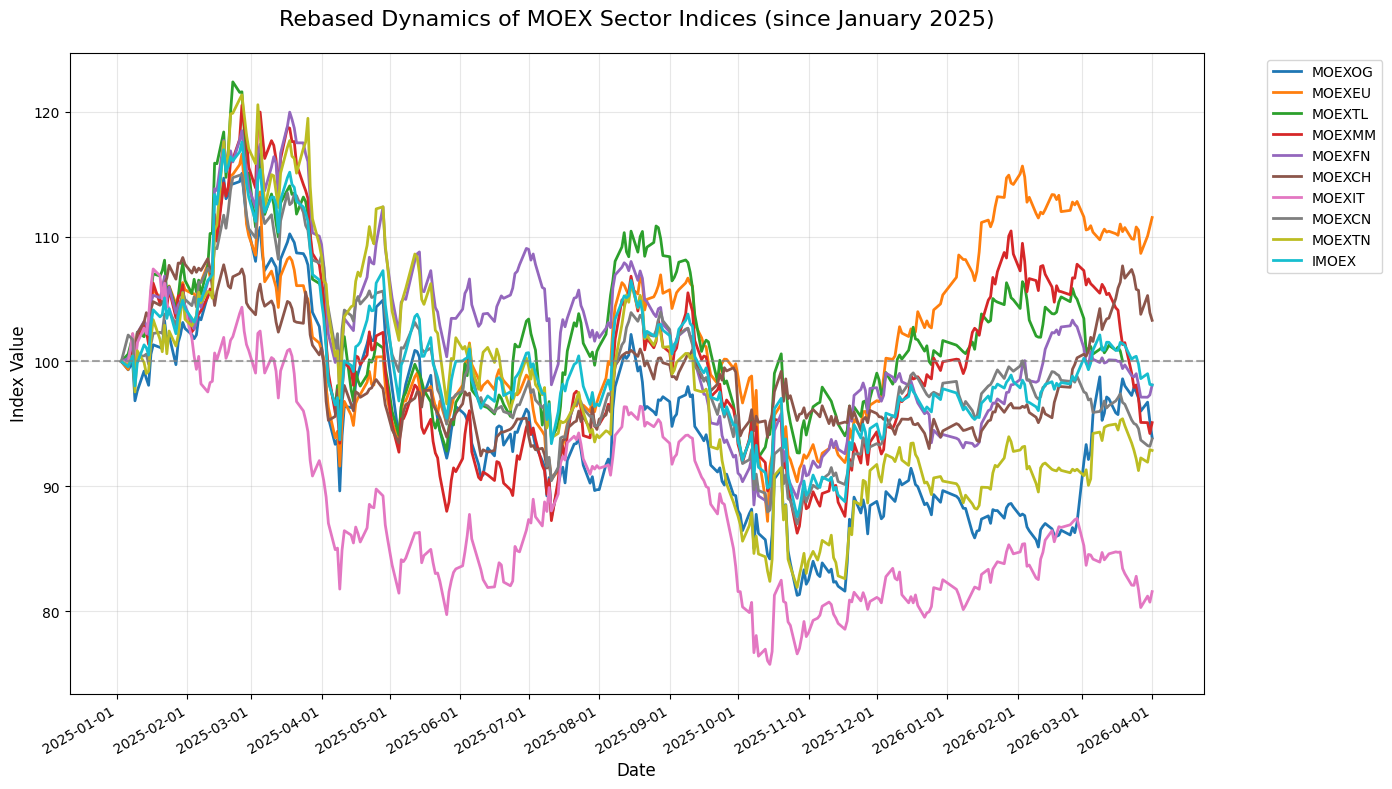

Index performance since January 2025:
MOEXOG: -6.10%
MOEXEU: +11.53%
MOEXTL: +nan%
MOEXMM: -4.90%
MOEXFN: -1.89%
MOEXCH: +3.30%
MOEXIT: -18.45%
MOEXCN: -6.21%
MOEXTN: -7.13%
IMOEX: -1.88%


In [ ]:
# Check if there is data for the selected period
if filtered_df_industry.empty:
    print("No data available for the specified period (January 2025 - September 2025)")
else:
    # Rebase indices: set the initial value to 100
    filtered_df_industry = filtered_df_industry.sort_index(ascending=True)
    rebased_df = (filtered_df_industry / filtered_df_industry.iloc[0] * 100)

    # Create the plot
    plt.figure(figsize=(14, 8))

    # Plot each index
    for column in rebased_df.columns:
        plt.plot(rebased_df.index, rebased_df[column], label=column, linewidth=2)

    # Plot settings
    plt.title('Rebased Dynamics of MOEX Sector Indices (since January 2025)', fontsize=16, pad=20)
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Index Value', fontsize=12)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)

    # Format dates on X-axis
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
    plt.gcf().autofmt_xdate()

    # Add horizontal reference line at 100
    plt.axhline(y=100, color='gray', linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

    # Print index performance statistics
    print("Index performance since January 2025:")
    for column in rebased_df.columns:
        change = rebased_df[column].iloc[-1] - 100
        change_percent = (rebased_df[column].iloc[-1] / 100 - 1) * 100
        print(f"{column}: {change_percent:+.2f}%")

# Weights of Companies in an Index

Below is an example using the MOEX Index, but the same approach can be applied to any index traded on the Moscow Exchange.

### Download as of Today’s Date

In [ ]:
import webbrowser
api_url='https://iss.moex.com/iss/statistics/engines/stock/markets/index/analytics/IMOEX.json'
with requests.Session() as session:
  data = apimoex.ISSClient(session, api_url).get_all()
df_tcr = pd.DataFrame(data['analytics'])
df_tcr.head(4)

,indexid,tradedate,ticker,shortnames,secids,weight,tradingsession,trade_session_date
0,IMOEX,2025-09-16,AFKS,Система ао,AFKS,0.47,3,2025-09-16
1,IMOEX,2025-09-16,AFLT,Аэрофлот,AFLT,0.79,3,2025-09-16
2,IMOEX,2025-09-16,ALRS,АЛРОСА ао,ALRS,0.76,3,2025-09-16
3,IMOEX,2025-09-16,ASTR,Астра ао,ASTR,0.20,3,2025-09-16


### Download for a Selected Period

To download data for a specific period, configure the parameters `start_date` and `end_date`.

Note that there may be a limitation with the `pagesize` parameter, as the source link displays only 20 companies from the MOEX Index.

Historical weights are available starting from **January 1, 2001**.

In [3]:
# Function to generate a list of dates
def generate_dates(start_date, end_date):
    dates = []
    current_date = start_date
    while current_date <= end_date:
        dates.append(current_date.strftime('%Y-%m-%d'))
        current_date += timedelta(days=1)
    return dates

# API URL
api_url = 'https://iss.moex.com/iss/statistics/engines/stock/markets/index/analytics/IMOEX.json'

# Start and end dates of the period
start_date = datetime.strptime('2025-08-01', '%Y-%m-%d')
end_date = datetime.strptime('2025-09-15', '%Y-%m-%d')

# Generate list of dates
dates = generate_dates(start_date, end_date)

# Create a session and send requests
all_data = []
with requests.Session() as session:
    for date in dates:
        start = 0
        while True:
            # Request parameters
            params = {
                'date': date,
                'start': start,
                'pagesize': 100  # Set page size
            }

            # Send request with parameters
            response = session.get(api_url, params=params)

            # Check if the request was successful
            if response.status_code == 200:
                data = response.json()

                # Check data structure
                if 'analytics' in data and 'data' in data['analytics'] and 'columns' in data['analytics']:
                    columns = data['analytics']['columns']

                    for item in data['analytics']['data']:
                        # Convert list to dictionary with column headers
                        item_dict = {header: value for header, value in zip(columns, item)}
                        item_dict['date'] = date  # Add date to the data
                        all_data.append(item_dict)

                    # Check if there is a cursor for the next page
                    if 'analytics.cursor' in data and len(data['analytics.cursor']['data']) > 0:
                        cursor_data = data['analytics.cursor']['data'][0]
                        total = cursor_data[1]
                        page_size = cursor_data[2]
                        start += page_size
                        if start >= total:
                            break
                    else:
                        break
                else:
                    break
            else:
                print(f"Request error for date {date}: {response.status_code}")
                break

# Convert all data into a DataFrame
df_weights = pd.DataFrame(all_data)

# Display DataFrame
print(df_weights.head(4))
print(df_weights.tail(4))

  indexid   tradedate ticker  shortnames secids  weight  tradingsession  \
0   IMOEX  2025-08-01   AFKS  Система ао   AFKS    0.50               3   
1   IMOEX  2025-08-01   AFLT    Аэрофлот   AFLT    0.76               3   
2   IMOEX  2025-08-01   ALRS   АЛРОСА ао   ALRS    0.77               3   
3   IMOEX  2025-08-01   ASTR   iАстра ао   ASTR    0.22               3   

  trade_session_date        date  
0         2025-08-01  2025-08-01  
1         2025-08-01  2025-08-01  
2         2025-08-01  2025-08-01  
3         2025-08-01  2025-08-01  
     indexid   tradedate ticker  shortnames secids  weight  tradingsession  \
1436   IMOEX  2025-09-15   UPRO   Юнипро ао   UPRO    0.20               3   
1437   IMOEX  2025-09-15   VKCO  МКПАО "ВК"   VKCO    0.44               3   
1438   IMOEX  2025-09-15   VTBR      ВТБ ао   VTBR    1.11               3   
1439   IMOEX  2025-09-15   YDEX      ЯНДЕКС   YDEX    4.51               3   

     trade_session_date        date  
1436         2025-09

### Get Information on Index Composition

You can track changes in the index composition using the `get_index_tickers` function.

In the following line, you can specify any index:

```python
data = apimoex.get_index_tickers(session, "MOEXOG")
```


In [ ]:
with requests.Session() as session:
        data = apimoex.get_index_tickers(session, "MOEXOG")
        df = pd.DataFrame(data)
df.tail(5)

,ticker,from,till,tradingsession
18,TATNP,2007-10-15,2025-09-19,3
19,TNBP,2011-01-25,2012-09-17,3
20,TNBPP,2011-04-25,2013-10-25,3
21,TRMK,2017-12-22,2020-03-19,3
22,TRNFP,2007-04-16,2025-09-19,3


# Commodity Price Quotes

Ticker symbols for commodities can be found at the following link:
[https://finance.yahoo.com/markets/commodities/](https://finance.yahoo.com/markets/commodities/)


In [ ]:
import yfinance as yf
import pandas as pd

# Define major commodity tickers
commodities = {
    'GC=F': 'Gold',
    'CL=F': 'Crude Oil',
    'SI=F': 'Silver',
    'PL=F': 'Platinum',
    'PA=F': 'Palladium',
    'HG=F': 'Copper',
    'NG=F': 'Natural Gas',
    'ZS=F': 'Soybeans',
    'ZC=F': 'Corn',
    'KE=F': 'Wheat',
    'ALI=F': 'Aluminum',
    'ZL=F': 'Lead'
}

# Download data
start_date = "2024-01-01"
end_date = "2025-10-31"

data_comm = yf.download(
    list(commodities.keys()),
    start=start_date,
    end=end_date
)["Close"]

# Rename columns for readability
data_comm.columns = [commodities[col] for col in data_comm.columns]

data_comm.tail(7)

/tmp/ipykernel_21111/352712489.py:24: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data_comm = yf.download(
[*********************100%***********************]  12 of 12 completed


,Aluminum,Crude Oil,Gold,Copper,Wheat,Natural Gas,Palladium,Platinum,Silver,Corn,Lead,Soybeans
Date,,,,,,,,,,,,
2025-10-22,2708.00,58.500000,4044.399902,4.9610,488.50,3.450,1439.699951,1536.000000,47.460999,423.00,50.070000,1034.75
2025-10-23,2768.75,61.790001,4125.500000,5.0820,500.00,3.344,1470.900024,1587.599976,48.481998,428.00,50.869999,1044.75
2025-10-24,2776.75,61.500000,4118.399902,5.0935,501.50,3.304,1463.599976,1593.900024,48.376999,423.25,50.270000,1041.75
2025-10-27,2800.25,61.310001,4001.899902,5.1405,514.25,3.442,1415.900024,1578.400024,46.562000,428.75,50.770000,1067.25
2025-10-28,2821.50,60.150002,3966.199951,5.1405,520.00,3.345,1402.699951,1577.000000,47.125000,432.00,50.259998,1078.25
2025-10-29,2829.25,60.480000,3983.699951,5.2335,522.75,3.376,1429.500000,1591.300049,47.721001,434.00,50.160000,1080.25
2025-10-30,2815.25,60.570000,4001.300049,5.0780,513.00,3.956,1461.500000,1608.300049,48.428001,430.25,49.650002,1091.25


In [ ]:
# Save to Excel
data_comm.to_excel('котировки_товаров.xlsx', sheet_name='Цены закрытия')

# Exchange rate (Parsing from CBR)

In [4]:
class CBRCurrencyParser:
    def __init__(self):
        # Initialize the object: set the base URL of the CBR API and HTTP headers
        self.base_url = "https://www.cbr.ru/scripts/XML_daily.asp"
        self.headers = {
            'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'
        }

    def get_currency_rates_for_date(self, date: datetime) -> List[Dict]:
        """
        Get exchange rates for a specific date
        """
        try:
            date_str = date.strftime("%d/%m/%Y")
            url = f"{self.base_url}?date_req={date_str}"  # Convert date to API format

            response = requests.get(url, headers=self.headers, timeout=10)
            response.raise_for_status()  # Send HTTP GET request with a 10-second timeout

            # Parse XML
            import xml.etree.ElementTree as ET
            root = ET.fromstring(response.content)

            rates = []
            for valute in root.findall('Valute'):
                rate_data = {
                    'date': date.strftime("%Y-%m-%d"),
                    'currency_id': valute.get('ID'),
                    'num_code': valute.find('NumCode').text,
                    'char_code': valute.find('CharCode').text,
                    'nominal': int(valute.find('Nominal').text),
                    'name': valute.find('Name').text,
                    'value': float(valute.find('Value').text.replace(',', '.')),
                    'vunit_rate': float(valute.find('VunitRate').text.replace(',', '.')) if valute.find('VunitRate') is not None else None
                }
                rates.append(rate_data)  # Create a dictionary with currency data

            print(f"Data retrieved for {date_str}: {len(rates)} currencies")
            return rates

        except Exception as e:
            print(f"Error retrieving data for {date.strftime('%Y-%m-%d')}: {e}")
            return []

    def get_currency_rates_period(self, start_date: str, end_date: str) -> List[Dict]:
        """
        Get exchange rates for a given period
        """
        start_dt = datetime.strptime(start_date, "%Y-%m-%d")
        end_dt = datetime.strptime(end_date, "%Y-%m-%d")

        all_rates = []
        current_date = start_dt

        while current_date <= end_dt:
            # Skip weekends (CBR does not publish rates on weekends)
            if current_date.weekday() < 5:  # 0–4 = Monday–Friday
                rates = self.get_currency_rates_for_date(current_date)
                all_rates.extend(rates)
                time.sleep(0.5)  # Pause between requests

            current_date += timedelta(days=1)  # Move to next day

        return all_rates

    def save_to_excel(self, data: List[Dict], filename: str):
        """
        Save data to an Excel file
        """
        if not data:
            print("No data to save")
            return

        # Create DataFrame
        df = pd.DataFrame(data)

        # Save to Excel
        try:
            with pd.ExcelWriter(filename, engine='openpyxl') as writer:
                # 1. Sheet: data in pivot format (dates as rows, currencies as columns)
                pivot_all = df.pivot_table(
                    values='value',
                    index='date',
                    columns='char_code',
                    aggfunc='first'
                )

                # Add nominal to currency names for clarity
                currency_info = df[['char_code', 'nominal']].drop_duplicates()
                currency_info_dict = dict(zip(currency_info['char_code'], currency_info['nominal']))

                # Rename columns to include nominal
                new_columns = {}
                for col in pivot_all.columns:
                    nominal = currency_info_dict.get(col, 1)
                    new_columns[col] = f"{col} ({nominal} units)"

                pivot_all = pivot_all.rename(columns=new_columns)
                pivot_all.to_excel(writer, sheet_name='All Data')

                # 2. Sheet: currency details
                currency_details = df[['char_code', 'num_code', 'name', 'nominal']].drop_duplicates()
                currency_details = currency_details.sort_values('char_code')
                currency_details.to_excel(writer, sheet_name='Currency Details', index=False)

                # 3. Sheet: major currencies
                major_currencies = ['USD', 'EUR', 'GBP', 'JPY', 'CNY', 'CHF']
                major_df = df[df['char_code'].isin(major_currencies)]

                if not major_df.empty:
                    pivot_major = major_df.pivot_table(
                        values='value',
                        index='date',
                        columns='char_code',
                        aggfunc='first'
                    )

                    new_columns_major = {}
                    for col in pivot_major.columns:
                        nominal = currency_info_dict.get(col, 1)
                        new_columns_major[col] = f"{col} ({nominal} units)"

                    pivot_major = pivot_major.rename(columns=new_columns_major)
                    pivot_major.to_excel(writer, sheet_name='Major Currencies')

                # 4. Sheet: raw data
                df.to_excel(writer, sheet_name='Raw Data', index=False)

            print(f"Data saved to file: {filename}")
            print(f"Total records: {len(df)}")
            print(f"Period: {df['date'].min()} - {df['date'].max()}")
            print(f"Number of currencies: {df['char_code'].nunique()}")

        except Exception as e:
            print(f"Error saving to Excel: {e}")

    def get_popular_currencies(self, data: List[Dict]) -> pd.DataFrame:
        """
        Get data for popular currencies
        """
        popular_codes = ['USD', 'EUR', 'GBP', 'JPY', 'CNY', 'CHF', 'TRY', 'KZT', 'UAH']
        popular_data = [x for x in data if x['char_code'] in popular_codes]
        return pd.DataFrame(popular_data)


# Main function
def main():
    # Create parser
    parser = CBRCurrencyParser()

    # Define period (can be changed)
    start_date = "2024-01-01"
    end_date = "2024-01-31"

    print(f"Starting CBR currency rates parsing")
    print(f"Period: {start_date} - {end_date}")
    print("-" * 50)

    # Get data
    currency_data = parser.get_currency_rates_period(start_date, end_date)

    if currency_data:
        # Create filename with timestamp
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        filename = f"currency_rates_{start_date}_to_{end_date}_{timestamp}.xlsx"

        # Save to Excel
        parser.save_to_excel(currency_data, filename)

        # Additional summary
        df = pd.DataFrame(currency_data)
        print("\n" + "="*50)
        print("SUMMARY:")
        print(f"Total records: {len(df)}")
        print(f"Unique currencies: {df['char_code'].nunique()}")
        print(f"Number of days: {df['date'].nunique()}")

        # Show latest rates for major currencies
        latest_date = df['date'].max()
        latest_rates = df[df['date'] == latest_date]
        popular = latest_rates[latest_rates['char_code'].isin(['USD', 'EUR', 'GBP', 'CNY'])]

        print(f"\nRates on {latest_date}:")
        for _, row in popular.iterrows():
            print(f"{row['char_code']}: {row['nominal']} {row['name']} = {row['value']} RUB")

    else:
        print("Failed to retrieve data")


if __name__ == "__main__":
    main()

Starting CBR currency rates parsing
Period: 2024-01-01 - 2024-01-31
--------------------------------------------------
Data retrieved for 01/01/2024: 43 currencies
Data retrieved for 02/01/2024: 43 currencies
Data retrieved for 03/01/2024: 43 currencies
Data retrieved for 04/01/2024: 43 currencies
Data retrieved for 05/01/2024: 43 currencies
Data retrieved for 08/01/2024: 43 currencies
Data retrieved for 09/01/2024: 43 currencies
Data retrieved for 10/01/2024: 43 currencies
Data retrieved for 11/01/2024: 43 currencies
Data retrieved for 12/01/2024: 43 currencies
Data retrieved for 15/01/2024: 43 currencies
Data retrieved for 16/01/2024: 43 currencies
Data retrieved for 17/01/2024: 43 currencies
Data retrieved for 18/01/2024: 43 currencies
Data retrieved for 19/01/2024: 43 currencies
Data retrieved for 22/01/2024: 43 currencies
Data retrieved for 23/01/2024: 43 currencies
Data retrieved for 24/01/2024: 43 currencies
Data retrieved for 25/01/2024: 43 currencies
Data retrieved for 26/01/2

## IMOEX in USD and RUB

In [5]:
import pandas as pd
import pandas_datareader as pdr
from datetime import datetime, timedelta
import time

# List of industry indices
tickers_industries = ["IMOEX"]
begin_date = '2025-01-01'

# Create an empty DataFrame to store data
df_industry = pd.DataFrame()

for ticker in tickers_industries:
    try:
        # Use MoexReader to retrieve data
        df = pdr.moex.MoexReader(ticker, start=begin_date)
        df1 = df.read_all_boards()[["CLOSE"]]

        # Check and handle duplicate index values
        if not df1.index.is_unique:
            df1 = df1[~df1.index.duplicated(keep='first')]

        # Merge data
        df_industry = pd.concat([df_industry, df1], axis=1)

    except Exception as e:
        print(f"Error processing ticker {ticker}: {str(e)}")
        continue

# Assign ticker names as column names
df_industry.columns = tickers_industries

# Get USD exchange rate for the same period
end_date = datetime.now().strftime("%Y-%m-%d")
parser = CBRCurrencyParser()
currency_data = parser.get_currency_rates_period(begin_date, end_date)

# Filter only USD and create DataFrame
usd_rates = []
for rate in currency_data:
    if rate['char_code'] == 'USD':
        usd_rates.append({
            'Date': pd.to_datetime(rate['date']),
            'USD_RUB': rate['value']
        })

df_usd = pd.DataFrame(usd_rates)
df_usd.set_index('Date', inplace=True)

# Merge index data with USD exchange rate
df_combined = df_industry.join(df_usd, how='left')

# Fill missing values (if any)
df_combined['USD_RUB'] = df_combined['USD_RUB'].fillna(method='ffill')

# Sort index in descending order (latest data first)
df_combined = df_combined.sort_index(ascending=False)

# Display results
print("MOEX index data with USD exchange rate:")
print(df_combined.head())

# Additionally: calculate index in USD
df_combined['IMOEX_USD'] = df_combined['IMOEX'] / df_combined['USD_RUB']

print("\nIMOEX index in USD:")
print(df_combined[['IMOEX', 'USD_RUB', 'IMOEX_USD']].head())

Data retrieved for 01/01/2025: 43 currencies
Data retrieved for 02/01/2025: 43 currencies
Data retrieved for 03/01/2025: 43 currencies
Data retrieved for 06/01/2025: 43 currencies
Data retrieved for 07/01/2025: 43 currencies
Data retrieved for 08/01/2025: 43 currencies
Data retrieved for 09/01/2025: 43 currencies
Data retrieved for 10/01/2025: 43 currencies
Data retrieved for 13/01/2025: 43 currencies
Data retrieved for 14/01/2025: 43 currencies
Data retrieved for 15/01/2025: 43 currencies
Data retrieved for 16/01/2025: 43 currencies
Data retrieved for 17/01/2025: 43 currencies
Data retrieved for 20/01/2025: 43 currencies
Data retrieved for 21/01/2025: 43 currencies
Data retrieved for 22/01/2025: 43 currencies
Data retrieved for 23/01/2025: 43 currencies
Data retrieved for 24/01/2025: 43 currencies
Data retrieved for 27/01/2025: 43 currencies
Data retrieved for 28/01/2025: 43 currencies
Data retrieved for 29/01/2025: 43 currencies
Data retrieved for 30/01/2025: 43 currencies
Data retri

/tmp/ipykernel_2845/2599079542.py:54: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_combined['USD_RUB'] = df_combined['USD_RUB'].fillna(method='ffill')


/tmp/ipykernel_2845/3187808788.py:2: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_combined['USD_RUB'] = df_combined['USD_RUB'].fillna(method='ffill')


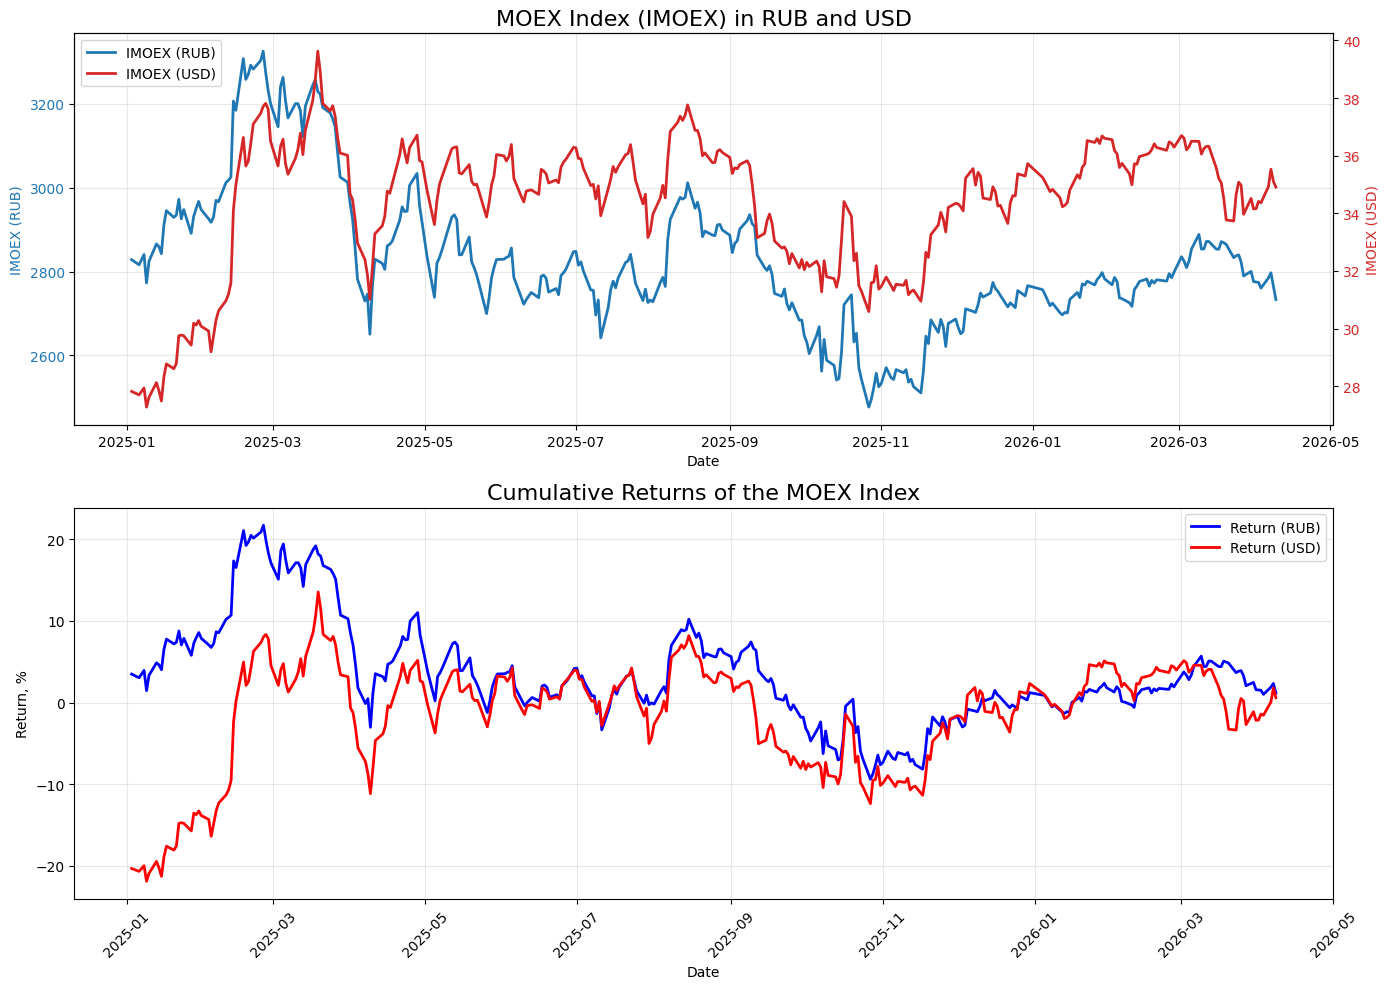

MOEX Index Statistics:
Period: 2025-01-03 - 2026-04-09
Initial IMOEX (RUB): 2828.50
Final IMOEX (RUB): 2733.40
Change in IMOEX (RUB): -3.36%
Initial IMOEX (USD): 27.82
Final IMOEX (USD): 34.91
Change in IMOEX (USD): 25.49%


In [6]:
# Fill missing values (if any)
df_combined['USD_RUB'] = df_combined['USD_RUB'].fillna(method='ffill')

# Calculate index in USD
df_combined['IMOEX_USD'] = df_combined['IMOEX'] / df_combined['USD_RUB']

# Calculate returns
df_combined['IMOEX_RUB_Return'] = df_combined['IMOEX'].pct_change()
df_combined['IMOEX_USD_Return'] = df_combined['IMOEX_USD'].pct_change()

# Calculate cumulative returns
df_combined['IMOEX_RUB_Cumulative'] = (1 + df_combined['IMOEX_RUB_Return']).cumprod() - 1
df_combined['IMOEX_USD_Cumulative'] = (1 + df_combined['IMOEX_USD_Return']).cumprod() - 1

# Sort index in ascending order for proper plotting
df_combined = df_combined.sort_index(ascending=True)

# Plot the results
plt.figure(figsize=(14, 10))

# Plot 1: Prices in RUB and USD
plt.subplot(2, 1, 1)

# Create two Y-axes
ax1 = plt.gca()        # first Y-axis
ax2 = ax1.twinx()     # second Y-axis

# IMOEX in RUB (left Y-axis)
color1 = 'tab:blue'
ax1.set_xlabel('Date')
ax1.set_ylabel('IMOEX (RUB)', color=color1)
line1 = ax1.plot(df_combined.index, df_combined['IMOEX'],
                 color=color1, label='IMOEX (RUB)', linewidth=2)
ax1.tick_params(axis='y', labelcolor=color1)

# IMOEX in USD (right Y-axis)
color2 = 'tab:red'
ax2.set_ylabel('IMOEX (USD)', color=color2)
line2 = ax2.plot(df_combined.index, df_combined['IMOEX_USD'],
                 color=color2, label='IMOEX (USD)', linewidth=2)
ax2.tick_params(axis='y', labelcolor=color2)

# Title and legend
plt.title('MOEX Index (IMOEX) in RUB and USD', fontsize=16)

# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

# Grid
ax1.grid(True, alpha=0.3)

# Format X-axis dates
plt.xticks(rotation=45)

# Plot 2: Cumulative returns
plt.subplot(2, 1, 2)
plt.plot(df_combined.index, df_combined['IMOEX_RUB_Cumulative'] * 100,
         label='Return (RUB)', linewidth=2, color='blue')
plt.plot(df_combined.index, df_combined['IMOEX_USD_Cumulative'] * 100,
         label='Return (USD)', linewidth=2, color='red')

plt.title('Cumulative Returns of the MOEX Index', fontsize=16)
plt.ylabel('Return, %')
plt.xlabel('Date')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

# Improve layout
plt.tight_layout()

# Show plot
plt.show()

# Additional: print statistics
print("MOEX Index Statistics:")
print(f"Period: {df_combined.index.min().strftime('%Y-%m-%d')} - {df_combined.index.max().strftime('%Y-%m-%d')}")
print(f"Initial IMOEX (RUB): {df_combined['IMOEX'].iloc[0]:.2f}")
print(f"Final IMOEX (RUB): {df_combined['IMOEX'].iloc[-1]:.2f}")
print(f"Change in IMOEX (RUB): {((df_combined['IMOEX'].iloc[-1] / df_combined['IMOEX'].iloc[0] - 1) * 100):.2f}%")
print(f"Initial IMOEX (USD): {df_combined['IMOEX_USD'].iloc[0]:.2f}")
print(f"Final IMOEX (USD): {df_combined['IMOEX_USD'].iloc[-1]:.2f}")
print(f"Change in IMOEX (USD): {((df_combined['IMOEX_USD'].iloc[-1] / df_combined['IMOEX_USD'].iloc[0] - 1) * 100):.2f}%")

# Return analysis

This script downloads historical stock price data for **SBER** from the **MOEX ISS API** and performs a basic time-series analysis. First, it plots the price series and applies the **Augmented Dickey-Fuller test** to check stationarity. Since stock prices are usually non-stationary, the series is then transformed into **daily returns**.

Next, the script evaluates whether the return series is normally distributed. This is done using both visual methods, such as a **histogram** and a **Q-Q plot**, and formal statistical tests, including the **Shapiro-Wilk test**, **Kolmogorov-Smirnov test**, and **Jarque-Bera test**. For each test, the null hypothesis (H0) and the alternative hypothesis (H1) are clearly stated, and the results are interpreted accordingly.


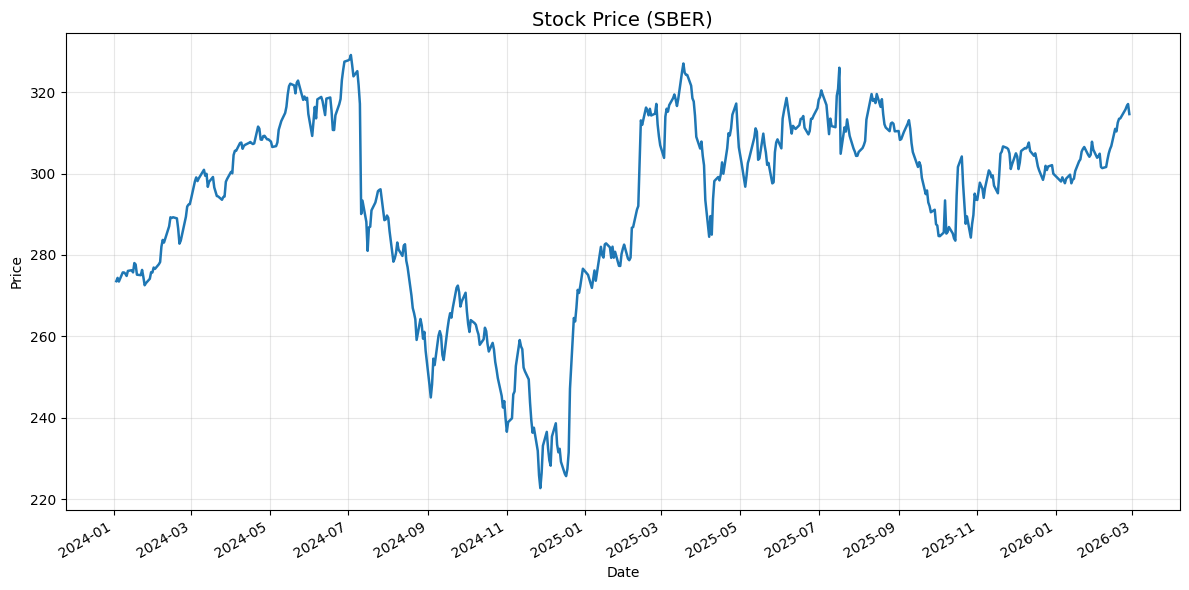

1. STATIONARITY OF THE PRICE SERIES
Conclusion: The price series is expected to be non-stationary.


In [4]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import scipy.stats as stats

from scipy.stats import shapiro, kstest, jarque_bera
from statsmodels.tsa.stattools import adfuller

# 1. Download stock quotes from MOEX
ticker = "SBER"
iss_url = "https://iss.moex.com/iss/history/engines/stock/markets/shares/boards/tqbr/securities/"
start_date = "2024-01-01"
end_date = "2026-02-27"
batch_size = 100

data = []

def get_stock_quotes(ticker: str):
    start = 0

    while True:
        url = f"{iss_url}{ticker}.json?from={start_date}&till={end_date}&start={start}"
        response = requests.get(url, timeout=20)

        if response.status_code != 200:
            print(f"Error retrieving data for {ticker}: {response.status_code}")
            break

        json_data = response.json()

        try:
            quotes = json_data["history"]["data"]

            if not quotes:
                break

            for quote in quotes:
                record = {
                    "TRADEDATE": quote[1],
                    "SECID": quote[3],
                    "LEGALCLOSEPRICE": quote[10],
                }
                data.append(record)

            cursor = json_data["history.cursor"]["data"][0]
            index, total, page_size = cursor[0], cursor[1], cursor[2]

            if index >= total:
                break

            start += page_size if page_size else batch_size

        except KeyError as e:
            print(f"Error processing data for {ticker}: {e}")
            break


get_stock_quotes(ticker)

if not data:
    raise ValueError("No data was retrieved.")

df = pd.DataFrame(data)
df["TRADEDATE"] = pd.to_datetime(df["TRADEDATE"])
df["LEGALCLOSEPRICE"] = pd.to_numeric(df["LEGALCLOSEPRICE"], errors="coerce")

df = df.dropna(subset=["LEGALCLOSEPRICE"])
df = df.sort_values("TRADEDATE")
df = df.set_index("TRADEDATE")

# Rename for convenience
df = df.rename(columns={"LEGALCLOSEPRICE": "PRICE"})

# 2. Plot stock price

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(df.index, df["PRICE"], linewidth=1.8)
ax.set_title(f"Stock Price ({ticker})", fontsize=14)
ax.set_xlabel("Date")
ax.set_ylabel("Price")
ax.grid(True, alpha=0.3)

# Fix overlapping dates
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
fig.autofmt_xdate()

plt.tight_layout()
plt.show()

print("=" * 60)
print("1. STATIONARITY OF THE PRICE SERIES")
print("=" * 60)
print("Conclusion: The price series is expected to be non-stationary.")



#### Augmented Dickey-Fuller (ADF) test ####

The **Augmented Dickey-Fuller (ADF) test** is used to determine whether a time series is **stationary** or **non-stationary**. The test checks for the presence of a **unit root**, which indicates non-stationarity.

The ADF regression is given by:

$$
\Delta y_t = \alpha + \beta y_{t-1} + \sum_{i=1}^{p} \gamma_i \Delta y_{t-i} + \varepsilon_t
$$

The key idea is to test the coefficient ( \beta ):

* If ( $ \beta $ = 0 ) → the series has a unit root → non-stationary
* If ( $ \beta $ < 0 ) → the series is stationary

**Hypotheses:**

* ( $ H_0 $ ): The series has a unit root (non-stationary)
* ( $ H_1 $ ): The series is stationary

**Decision rule:**

* If p-value < 0.05 → reject ( $ H_0 $ ) → stationary
* If p-value ≥ 0.05 → fail to reject ( $ H_0 $ ) → non-stationary

In financial data, price series are typically non-stationary, so they are usually transformed into returns for analysis.


In [2]:
# 3. Augmented Dickey-Fuller test for price

adf_price = adfuller(df["PRICE"].dropna())

print("\nAugmented Dickey-Fuller Test (Price Series)")
print("H0: The series has a unit root (the series is non-stationary).")
print("H1: The series does not have a unit root (the series is stationary).")
print(f"ADF Statistic: {adf_price[0]:.6f}")
print(f"p-value: {adf_price[1]:.6f}")

if adf_price[1] < 0.05:
    print("Decision: Reject H0.")
    print("Interpretation: The price series is stationary.")
else:
    print("Decision: Fail to reject H0.")
    print("Interpretation: The price series is non-stationary.")


Augmented Dickey-Fuller Test (Price Series)
H0: The series has a unit root (the series is non-stationary).
H1: The series does not have a unit root (the series is stationary).
ADF Statistic: -2.026080
p-value: 0.275256
Decision: Fail to reject H0.
Interpretation: The price series is non-stationary.



2. STATIONARITY OF THE RETURN SERIES
Augmented Dickey-Fuller Test (Return Series)
H0: The series has a unit root (the series is non-stationary).
H1: The series does not have a unit root (the series is stationary).
ADF Statistic: -19.399399
p-value: 0.000000
Decision: Reject H0.
Interpretation: The return series is stationary.


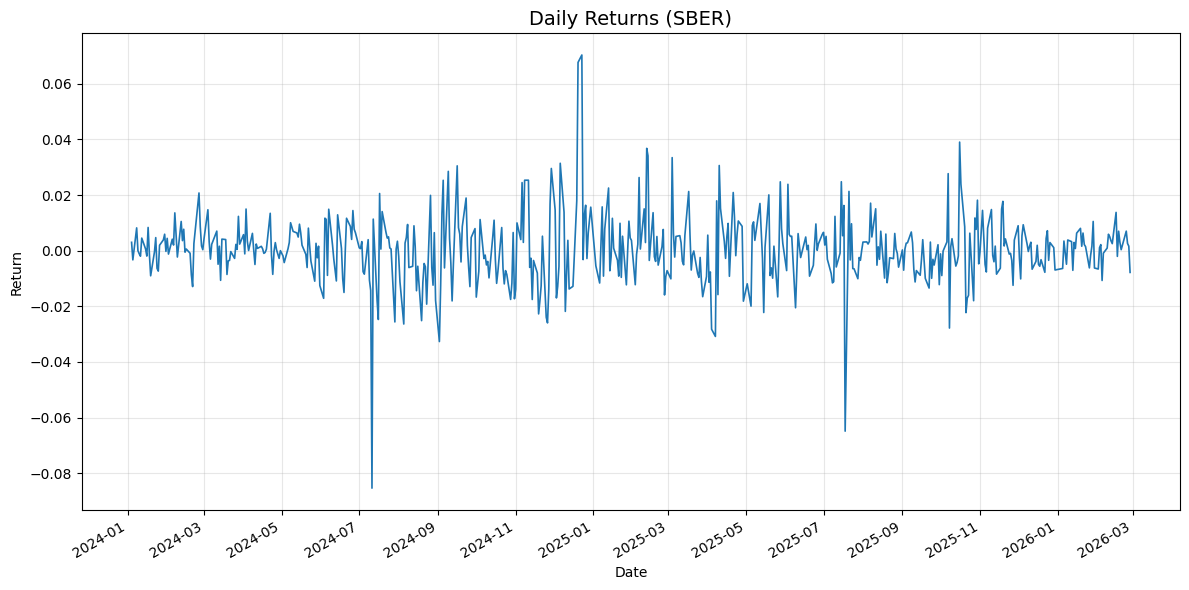

In [3]:
# 4. Convert prices to returns

df["RETURN"] = df["PRICE"].pct_change()
returns = df["RETURN"].dropna()

# Optional: check stationarity of returns
adf_ret = adfuller(returns)

print("\n" + "=" * 60)
print("2. STATIONARITY OF THE RETURN SERIES")
print("=" * 60)
print("Augmented Dickey-Fuller Test (Return Series)")
print("H0: The series has a unit root (the series is non-stationary).")
print("H1: The series does not have a unit root (the series is stationary).")
print(f"ADF Statistic: {adf_ret[0]:.6f}")
print(f"p-value: {adf_ret[1]:.6f}")

if adf_ret[1] < 0.05:
    print("Decision: Reject H0.")
    print("Interpretation: The return series is stationary.")
else:
    print("Decision: Fail to reject H0.")
    print("Interpretation: The return series is non-stationary.")

# Plot returns
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(returns.index, returns, linewidth=1.2)
ax.set_title(f"Daily Returns ({ticker})", fontsize=14)
ax.set_xlabel("Date")
ax.set_ylabel("Return")
ax.grid(True, alpha=0.3)

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
fig.autofmt_xdate()

plt.tight_layout()
plt.show()

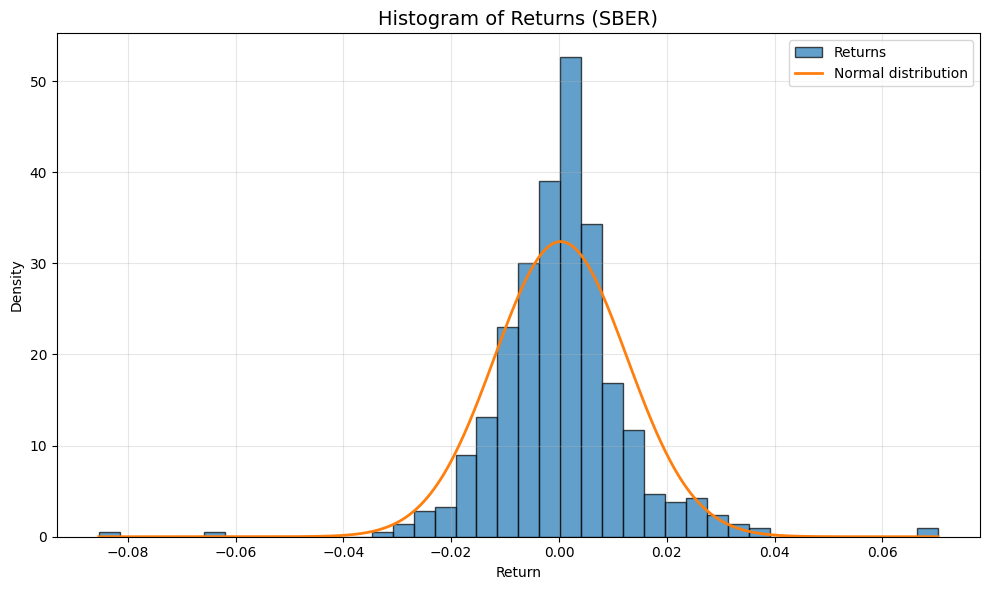


3. NORMALITY CHECK: HISTOGRAM
H0: Returns are normally distributed.
H1: Returns are not normally distributed.
Interpretation: Compare the histogram shape with the normal curve.
If the histogram deviates from the bell shape, H0 is not supported visually.


In [5]:
# 5. Histogram: compare with normal distribution

# Histogram
fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(returns, bins=40, density=True, alpha=0.7, edgecolor="black", label="Returns")

# Parameters of normal distribution
mu = returns.mean()
sigma = returns.std(ddof=1)

# Generate values for normal curve
x = np.linspace(returns.min(), returns.max(), 500)
normal_pdf = stats.norm.pdf(x, mu, sigma)

# Plot normal distribution
ax.plot(x, normal_pdf, linewidth=2, label="Normal distribution")

# Styling
ax.set_title(f"Histogram of Returns ({ticker})", fontsize=14)
ax.set_xlabel("Return")
ax.set_ylabel("Density")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("3. NORMALITY CHECK: HISTOGRAM")
print("=" * 60)
print("H0: Returns are normally distributed.")
print("H1: Returns are not normally distributed.")
print("Interpretation: Compare the histogram shape with the normal curve.")
print("If the histogram deviates from the bell shape, H0 is not supported visually.")

#### **Q-Q (Quantile-Quantile) Plot** ####

The **Q-Q (Quantile-Quantile) Plot** is a graphical method used to assess whether a dataset follows a **normal distribution**. It compares the quantiles of the observed data with the quantiles of a theoretical normal distribution.

If the data are normally distributed, the points on the Q-Q plot will lie approximately along a **straight diagonal line**. Deviations from this line indicate departures from normality:

* systematic curvature suggests skewness
* strong deviations at the tails indicate **fat tails** or outliers

**Hypotheses:**

* ( $ H_0 $ ): Returns are normally distributed
* ( $ H_1 $ ): Returns are not normally distributed

**Interpretation:**

* If points lie close to a straight line → fail to reject ( $ H_0 $ )
* If points significantly deviate from the line → reject ( $ H_0 $ )

In financial time series, Q-Q plots often show deviations in the tails, indicating that returns are not perfectly normally distributed.



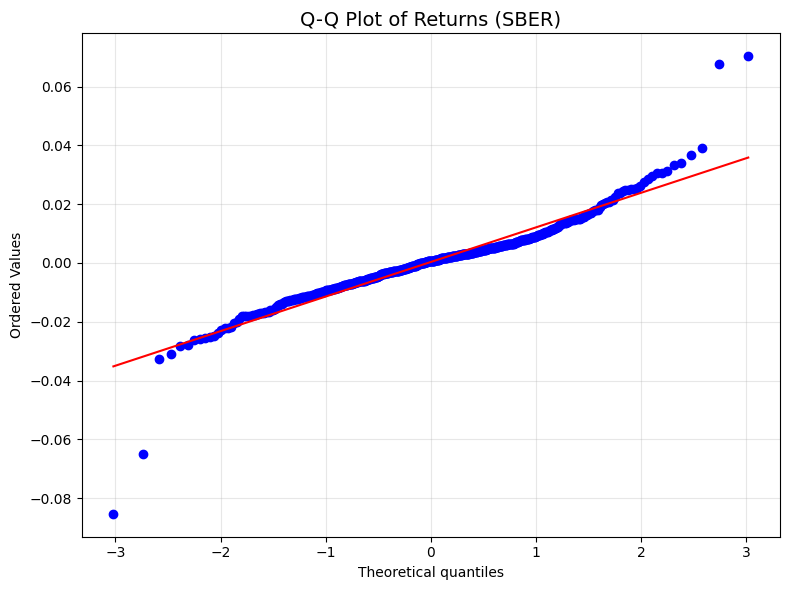


4. NORMALITY CHECK: Q-Q PLOT
H0: Returns are normally distributed.
H1: Returns are not normally distributed.
Interpretation: If the points lie approximately on a straight line, H0 is supported.
Strong deviations from the straight line indicate that H0 is not supported.


In [6]:
# 6. Q-Q Plot
fig, ax = plt.subplots(figsize=(8, 6))
stats.probplot(returns, dist="norm", plot=ax)
ax.set_title(f"Q-Q Plot of Returns ({ticker})", fontsize=14)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("4. NORMALITY CHECK: Q-Q PLOT")
print("=" * 60)
print("H0: Returns are normally distributed.")
print("H1: Returns are not normally distributed.")
print("Interpretation: If the points lie approximately on a straight line, H0 is supported.")
print("Strong deviations from the straight line indicate that H0 is not supported.")

#### Statistical Tests ####

##### **Shapiro–Wilk Test**

The **Shapiro–Wilk test** is a statistical test used to check whether a dataset follows a **normal distribution**. It is particularly powerful for small samples, although it can be overly sensitive for large datasets.

* **H₀:** Returns are normally distributed
* **H₁:** Returns are not normally distributed

**Decision rule:**
If the p-value is less than 0.05, reject ( H_0 ) and conclude that the data are not normally distributed.


In [19]:
# Shapiro-Wilk test

# Shapiro-Wilk can be sensitive for large samples, but it is still commonly reported.
shapiro_stat, shapiro_p = shapiro(returns)

print("\n" + "=" * 60)
print("SHAPIRO-WILK TEST")
print("=" * 60)
print("H0: Returns are normally distributed.")
print("H1: Returns are not normally distributed.")
print(f"Test statistic: {shapiro_stat:.6f}")
print(f"p-value: {shapiro_p:.6f}")

if shapiro_p < 0.05:
    print("Decision: Reject H0.")
    print("Interpretation: Returns are not normally distributed.")
else:
    print("Decision: Fail to reject H0.")
    print("Interpretation: There is not enough evidence to reject normality.")


SHAPIRO-WILK TEST
H0: Returns are normally distributed.
H1: Returns are not normally distributed.
Test statistic: 0.911813
p-value: 0.000000
Decision: Reject H0.
Interpretation: Returns are not normally distributed.



##### **Kolmogorov–Smirnov Test**

The **Kolmogorov–Smirnov (K–S) test** compares the empirical distribution of the data with a theoretical distribution (in this case, normal). Before applying the test, the data are typically standardized.

* **H₀:** Returns follow a normal distribution
* **H₁:** Returns do not follow a normal distribution

**Decision rule:**
If the p-value is less than 0.05, reject ( H_0 ) and conclude that the data do not follow a normal distribution.

In [21]:
# Kolmogorov-Smirnov test

# Standardize returns before K-S test against standard normal
returns_std = (returns - returns.mean()) / returns.std(ddof=1)
ks_stat, ks_p = kstest(returns_std, "norm")

print("\n" + "=" * 60)
print("KOLMOGOROV-SMIRNOV TEST")
print("=" * 60)
print("H0: Returns follow a normal distribution.")
print("H1: Returns do not follow a normal distribution.")
print(f"Test statistic: {ks_stat:.6f}")
print(f"p-value: {ks_p:.6f}")

if ks_p < 0.05:
    print("Decision: Reject H0.")
    print("Interpretation: Returns do not follow a normal distribution.")
else:
    print("Decision: Fail to reject H0.")
    print("Interpretation: There is not enough evidence to reject normality.")



KOLMOGOROV-SMIRNOV TEST
H0: Returns follow a normal distribution.
H1: Returns do not follow a normal distribution.
Test statistic: 0.091582
p-value: 0.000192
Decision: Reject H0.
Interpretation: Returns do not follow a normal distribution.


##### **Jarque–Bera Test**

The **Jarque–Bera test** evaluates normality based on **skewness** and **kurtosis** of the data. It is commonly used in financial analysis.

* **H₀:** Returns are normally distributed
* **H₁:** Returns are not normally distributed

**Decision rule:**
If the p-value is less than 0.05, reject ( H_0 ) and conclude that the data are not normally distributed.


In [22]:
# Jarque-Bera test

jb_stat, jb_p = jarque_bera(returns)

print("\n" + "=" * 60)
print("JARQUE-BERA TEST")
print("=" * 60)
print("H0: Returns are normally distributed.")
print("H1: Returns are not normally distributed.")
print(f"Test statistic: {jb_stat:.6f}")
print(f"p-value: {jb_p:.6f}")

if jb_p < 0.05:
    print("Decision: Reject H0.")
    print("Interpretation: Returns are not normally distributed.")
else:
    print("Decision: Fail to reject H0.")
    print("Interpretation: There is not enough evidence to reject normality.")


JARQUE-BERA TEST
H0: Returns are normally distributed.
H1: Returns are not normally distributed.
Test statistic: 1674.516215
p-value: 0.000000
Decision: Reject H0.
Interpretation: Returns are not normally distributed.


* Non-normality of returns is a typical feature of financial data
* Return distributions often display skewness, excess kurtosis, and the presence of outliers
* One possible adjustment is to use log returns instead of simple returns, as this transformation can stabilize variance and reduce asymmetry
* Another approach is to apply outlier treatment (e.g., winsorization) to limit the influence of extreme observations
* It should be noted that such transformations do not guarantee normality
* In practice, it is often more appropriate to use models that do not rely on the normality assumption, such as heavy-tailed distributions (e.g., Student’s t) or volatility models like GARCH


### Calculation of different metrics ###

#### Basic return metrics ####

In [25]:
arith_mean = returns.mean()
geom_mean = (1 + returns).prod()**(1/len(returns)) - 1

print("\n" + "=" * 60)
print("RETURN METRICS")
print("=" * 60)
print(f"Arithmetic mean return: {arith_mean:.6f}")
print(f"Geometric mean return: {geom_mean:.6f}")


RETURN METRICS
Arithmetic mean return: 0.000332
Geometric mean return: 0.000256


In [26]:
# Number of trading days in a year
trading_days = 252

# Annualized arithmetic mean
arith_annual = returns.mean() * trading_days

# Annualized geometric mean
geom_annual = (1 + returns).prod()**(trading_days / len(returns)) - 1

print("\n" + "=" * 60)
print("ANNUALIZED RETURN METRICS")
print("=" * 60)
print(f"Annualized arithmetic return: {arith_annual:.6f}")
print(f"Annualized geometric return: {geom_annual:.6f}")


ANNUALIZED RETURN METRICS
Annualized arithmetic return: 0.083573
Annualized geometric return: 0.066580


#### Risk measures ####

In [27]:
variance = returns.var(ddof=1)
std_dev = returns.std(ddof=1)
mad = (returns - returns.mean()).abs().mean()

print("\n" + "=" * 60)
print("RISK MEASURES")
print("=" * 60)
print(f"Variance: {variance:.6f}")
print(f"Standard deviation: {std_dev:.6f}")
print(f"Mean absolute deviation: {mad:.6f}")


RISK MEASURES
Variance: 0.000152
Standard deviation: 0.012319
Mean absolute deviation: 0.008444


In [28]:
# Number of trading days in a year
trading_days = 252

# Annualization
variance_annual = variance * trading_days
std_dev_annual = std_dev * np.sqrt(trading_days)
mad_annual = mad * np.sqrt(trading_days)

print("\n" + "=" * 60)
print("ANNUALIZED RISK MEASURES")
print("=" * 60)
print(f"Annualized variance: {variance_annual:.6f}")
print(f"Annualized standard deviation (volatility): {std_dev_annual:.6f}")
print(f"Annualized mean absolute deviation: {mad_annual:.6f}")


ANNUALIZED RISK MEASURES
Annualized variance: 0.038244
Annualized standard deviation (volatility): 0.195561
Annualized mean absolute deviation: 0.134042


#### VaR and Expected Shortfall ####

In [29]:
confidence = 0.95
VaR = np.quantile(returns, 1 - confidence)
ES = returns[returns <= VaR].mean()

print("\n" + "=" * 60)
print("RISK MEASURES: VaR & ES")
print("=" * 60)
print(f"VaR (95%): {VaR:.6f}")
print(f"Expected Shortfall (95%): {ES:.6f}")


5. RISK MEASURES: VaR & ES
VaR (95%): -0.017242
Expected Shortfall (95%): -0.026100


The **Value at Risk (VaR) at the 95% confidence level** is **−1.72%**, which means that under normal market conditions, the daily loss of the asset is **not expected to exceed 1.72% with 95% probability**. There is only a **5% chance** that the loss will be greater than this value on any given day.

The **Expected Shortfall (ES) at the 95% level** is **−2.61%**, which measures the **average loss in the worst 5% of cases**. This indicates that when losses exceed the VaR threshold, they are on average around **2.61%**, reflecting more severe downside risk.

Overall, the fact that ES is significantly lower than VaR suggests the presence of **fat tails** in the return distribution, meaning that extreme losses are more pronounced than would be expected under normal distribution assumptions.

#### Skewness & excess kurtosis ####

In [31]:
skewness = stats.skew(returns, bias=False)
kurtosis = stats.kurtosis(returns, fisher=True, bias=False)  # excess kurtosis

print("\n" + "=" * 60)
print("DISTRIBUTION METRICS")
print("=" * 60)
print(f"Skewness: {skewness:.6f}")
print(f"Excess kurtosis: {kurtosis:.6f}")


DISTRIBUTION METRICS
Skewness: -0.067357
Excess kurtosis: 8.660352


The return distribution shows **slightly negative skewness** (−0.067), indicating a small tendency toward more extreme negative returns. The **high excess kurtosis** (8.66) suggests the presence of **fat tails**, meaning that extreme values occur more frequently than in a normal distribution.


### Conduct portfolio ###

In [33]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import scipy.stats as stats

from scipy.stats import shapiro, kstest, jarque_bera
from statsmodels.tsa.stattools import adfuller

# SETTINGS
tickers = ["SBER", "GAZP", "LKOH"]
start_date = "2024-01-01"
end_date = "2026-02-27"
batch_size = 100

iss_url = "https://iss.moex.com/iss/history/engines/stock/markets/shares/boards/tqbr/securities/"

# DOWNLOAD PRICES FROM MOEX
all_data = []

def get_stock_quotes(ticker: str):
    start = 0

    while True:
        url = f"{iss_url}{ticker}.json?from={start_date}&till={end_date}&start={start}"
        response = requests.get(url, timeout=20)

        if response.status_code != 200:
            print(f"Error retrieving data for {ticker}: {response.status_code}")
            break

        json_data = response.json()

        try:
            quotes = json_data["history"]["data"]
            if not quotes:
                break

            for quote in quotes:
                record = {
                    "TRADEDATE": quote[1],
                    "SECID": quote[3],
                    "LEGALCLOSEPRICE": quote[10],
                }
                all_data.append(record)

            cursor = json_data["history.cursor"]["data"][0]
            index, total, page_size = cursor[0], cursor[1], cursor[2]

            if index >= total:
                break

            start += page_size if page_size else batch_size

        except KeyError as e:
            print(f"Error processing data for {ticker}: {e}")
            break


for ticker in tickers:
    get_stock_quotes(ticker)

if not all_data:
    raise ValueError("No data was retrieved.")

df = pd.DataFrame(all_data)
df["TRADEDATE"] = pd.to_datetime(df["TRADEDATE"])
df["LEGALCLOSEPRICE"] = pd.to_numeric(df["LEGALCLOSEPRICE"], errors="coerce")
df = df.dropna(subset=["LEGALCLOSEPRICE"])

prices = (
    df.pivot_table(index="TRADEDATE", columns="SECID", values="LEGALCLOSEPRICE", aggfunc="first")
      .sort_index()
)

prices = prices[tickers].dropna()

print("=" * 70)
print("PRICE DATA")
print("=" * 70)
print(prices.head())
print(prices.tail())

PRICE DATA
SECID         SBER    GAZP    LKOH
TRADEDATE                         
2024-01-03  273.55  161.06  6778.5
2024-01-04  274.37  161.23  6784.0
2024-01-05  273.46  161.72  6781.0
2024-01-08  275.70  162.81  6782.5
2024-01-09  275.70  162.30  6864.0
SECID         SBER    GAZP    LKOH
TRADEDATE                         
2026-02-20  313.58  125.80  5184.5
2026-02-24  315.78  127.52  5207.5
2026-02-25  316.60  126.94  5169.0
2026-02-26  317.11  127.10  5153.0
2026-02-27  314.63  127.04  5191.5


In [39]:
# FUNCTION TO CALCULATE ASSET METRICS
def calculate_asset_metrics(return_series: pd.Series, confidence=0.95):
    r = return_series.dropna()

    arithmetic_mean = r.mean()
    geometric_mean = (1 + r).prod() ** (1 / len(r)) - 1
    variance = r.var(ddof=1)
    std_dev = r.std(ddof=1)
    mad = (r - r.mean()).abs().mean()

    # Historical VaR and ES in return terms
    var_level = np.quantile(r, 1 - confidence)
    es = r[r <= var_level].mean()

    skewness = stats.skew(r, bias=False)
    excess_kurtosis = stats.kurtosis(r, fisher=True, bias=False)

    return {
        "Expected return (arith. mean)": arithmetic_mean,
        "Geometric mean return": geometric_mean,
        "Variance": variance,
        "Standard deviation": std_dev,
        "Mean absolute deviation": mad,
        "VaR 95%": var_level,
        "Expected Shortfall 95%": es,
        "Skewness": skewness,
        "Excess kurtosis": excess_kurtosis,
    }

In [40]:
# RETURNS
simple_returns = prices.pct_change().dropna()
log_returns = np.log(prices / prices.shift(1)).dropna()

# METRICS FOR EACH STOCK
asset_metrics = {}
for ticker in tickers:
    asset_metrics[ticker] = calculate_asset_metrics(simple_returns[ticker])

asset_metrics_df = pd.DataFrame(asset_metrics).T

print("\n" + "=" * 70)
print("ASSET METRICS")
print("=" * 70)
print(asset_metrics_df.round(6))

# TWO-ASSET PORTFOLIO
# Preliminary portfolio of two stocks: SBER and GAZP
weights_2 = np.array([0.5, 0.5])
returns_2 = simple_returns[["SBER", "GAZP"]]
portfolio_2 = returns_2 @ weights_2

# Portfolio expected return and risk
mean_vector_2 = returns_2.mean().values
cov_matrix_2 = returns_2.cov().values

expected_return_2 = weights_2 @ mean_vector_2
variance_2 = weights_2 @ cov_matrix_2 @ weights_2
std_2 = np.sqrt(variance_2)

metrics_2 = calculate_asset_metrics(portfolio_2)
corr_2 = returns_2.corr()

print("\n" + "=" * 70)
print("TWO-ASSET PORTFOLIO: SBER + GAZP")
print("=" * 70)
print(f"Weights: SBER = {weights_2[0]:.2f}, GAZP = {weights_2[1]:.2f}")
print(f"Portfolio expected return: {expected_return_2:.6f}")
print(f"Portfolio variance: {variance_2:.6f}")
print(f"Portfolio standard deviation: {std_2:.6f}")
print("\nCorrelation matrix:")
print(corr_2.round(4))

print("\nAdditional metrics:")
for k, v in metrics_2.items():
    print(f"{k}: {v:.6f}")


# THREE-ASSET PORTFOLIO
# Add LKOH to show diversification effect
weights_3 = np.array([0.4, 0.3, 0.3])
returns_3 = simple_returns[["SBER", "GAZP", "LKOH"]]
portfolio_3 = returns_3 @ weights_3

mean_vector_3 = returns_3.mean().values
cov_matrix_3 = returns_3.cov().values

expected_return_3 = weights_3 @ mean_vector_3
variance_3 = weights_3 @ cov_matrix_3 @ weights_3
std_3 = np.sqrt(variance_3)

metrics_3 = calculate_asset_metrics(portfolio_3)
corr_3 = returns_3.corr()

print("\n" + "=" * 70)
print("THREE-ASSET PORTFOLIO: SBER + GAZP + LKOH")
print("=" * 70)
print(f"Weights: SBER = {weights_3[0]:.2f}, GAZP = {weights_3[1]:.2f}, LKOH = {weights_3[2]:.2f}")
print(f"Portfolio expected return: {expected_return_3:.6f}")
print(f"Portfolio variance: {variance_3:.6f}")
print(f"Portfolio standard deviation: {std_3:.6f}")
print("\nCorrelation matrix:")
print(corr_3.round(4))

print("\nAdditional metrics:")
for k, v in metrics_3.items():
    print(f"{k}: {v:.6f}")



ASSET METRICS
      Expected return (arith. mean)  Geometric mean return  Variance  \
SBER                       0.000332               0.000256  0.000152   
GAZP                      -0.000283              -0.000434  0.000303   
LKOH                      -0.000402              -0.000488  0.000171   

      Standard deviation  Mean absolute deviation   VaR 95%  \
SBER            0.012319                 0.008444 -0.017242   
GAZP            0.017419                 0.012581 -0.027395   
LKOH            0.013082                 0.009075 -0.020019   

      Expected Shortfall 95%  Skewness  Excess kurtosis  
SBER               -0.026100 -0.067357         8.660352  
GAZP               -0.037000  0.544856         3.139634  
LKOH               -0.031588 -0.485629         4.167833  

TWO-ASSET PORTFOLIO: SBER + GAZP
Weights: SBER = 0.50, GAZP = 0.50
Portfolio expected return: 0.000024
Portfolio variance: 0.000183
Portfolio standard deviation: 0.013528

Correlation matrix:
SECID    SBER    G


DIVERSIFICATION EFFECT
                     Portfolio  Expected return  Variance  Standard deviation  \
0        2 assets (SBER, GAZP)         0.000024  0.000183            0.013528   
1  3 assets (SBER, GAZP, LKOH)        -0.000073  0.000145            0.012051   

    VaR 95%  Expected Shortfall 95%  Skewness  Excess kurtosis  
0 -0.022603               -0.027920  0.545033         2.561220  
1 -0.018494               -0.025345  0.480563         2.367189  

Conclusion: Adding the third asset reduces portfolio risk (standard deviation).
This demonstrates the diversification effect.


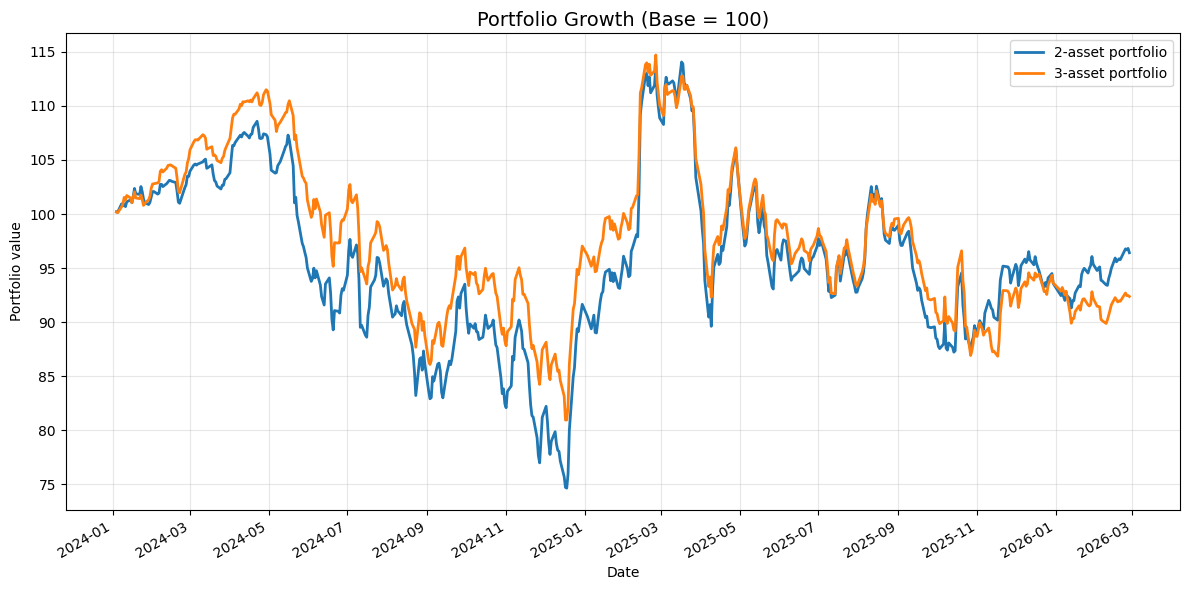

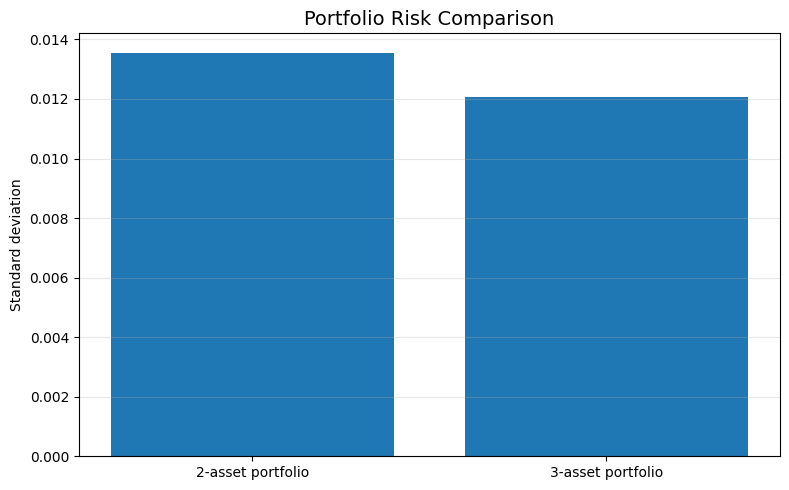

In [41]:
# DIVERSIFICATION EFFECT
comparison = pd.DataFrame({
    "Portfolio": ["2 assets (SBER, GAZP)", "3 assets (SBER, GAZP, LKOH)"],
    "Expected return": [expected_return_2, expected_return_3],
    "Variance": [variance_2, variance_3],
    "Standard deviation": [std_2, std_3],
    "VaR 95%": [metrics_2["VaR 95%"], metrics_3["VaR 95%"]],
    "Expected Shortfall 95%": [metrics_2["Expected Shortfall 95%"], metrics_3["Expected Shortfall 95%"]],
    "Skewness": [metrics_2["Skewness"], metrics_3["Skewness"]],
    "Excess kurtosis": [metrics_2["Excess kurtosis"], metrics_3["Excess kurtosis"]],
})

print("\n" + "=" * 70)
print("DIVERSIFICATION EFFECT")
print("=" * 70)
print(comparison.round(6))

if std_3 < std_2:
    print("\nConclusion: Adding the third asset reduces portfolio risk (standard deviation).")
    print("This demonstrates the diversification effect.")
else:
    print("\nConclusion: In this sample, adding the third asset did not reduce standard deviation.")
    print("This may happen if the added asset is highly correlated with the existing portfolio.")

# PLOT PORTFOLIO DYNAMICS
portfolio_prices = pd.DataFrame(index=returns_3.index)
portfolio_prices["Portfolio_2"] = (1 + portfolio_2).cumprod() * 100
portfolio_prices["Portfolio_3"] = (1 + portfolio_3).cumprod() * 100

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(portfolio_prices.index, portfolio_prices["Portfolio_2"], label="2-asset portfolio", linewidth=2)
ax.plot(portfolio_prices.index, portfolio_prices["Portfolio_3"], label="3-asset portfolio", linewidth=2)

ax.set_title("Portfolio Growth (Base = 100)", fontsize=14)
ax.set_xlabel("Date")
ax.set_ylabel("Portfolio value")
ax.legend()
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

# OPTIONAL: BAR CHART OF RISKS
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(["2-asset portfolio", "3-asset portfolio"], [std_2, std_3])
ax.set_title("Portfolio Risk Comparison", fontsize=14)
ax.set_ylabel("Standard deviation")
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

#### Portfolio with dividends ####

In [46]:
for ticker in tickers:
    print(f"\n{ticker} dividend events:")
    div_events = dividends_on_calendar.loc[dividends_on_calendar[f"{ticker}_div"] > 0, [f"{ticker}_div"]]
    print(div_events)


SBER dividend events:
            SBER_div
TRADEDATE           
2024-07-11     33.30
2025-07-18     34.84

GAZP dividend events:
Empty DataFrame
Columns: [GAZP_div]
Index: []

LKOH dividend events:
            LKOH_div
TRADEDATE           
2024-05-07     498.0
2024-12-17     514.0
2025-06-03     541.0


PRICE DATA
SECID         SBER    GAZP    LKOH
TRADEDATE                         
2024-01-03  273.55  161.06  6778.5
2024-01-04  274.37  161.23  6784.0
2024-01-05  273.46  161.72  6781.0
2024-01-08  275.70  162.81  6782.5
2024-01-09  275.70  162.30  6864.0
SECID         SBER    GAZP    LKOH
TRADEDATE                         
2026-02-20  313.58  125.80  5184.5
2026-02-24  315.78  127.52  5207.5
2026-02-25  316.60  126.94  5169.0
2026-02-26  317.11  127.10  5153.0
2026-02-27  314.63  127.04  5191.5

DIVIDEND DATA ALIGNED TO TRADING DAYS
            SBER_div  GAZP_div  LKOH_div
TRADEDATE                               
2024-05-07      0.00       0.0     498.0
2024-07-11     33.30       0.0       0.0
2024-12-17      0.00       0.0     514.0
2025-06-03      0.00       0.0     541.0
2025-07-18     34.84       0.0       0.0

PORTFOLIO COMPARISON
                    Portfolio  Cumulative return  Mean daily return  \
0  2 assets without dividends          -0.035785           0.000024   
1     2 a

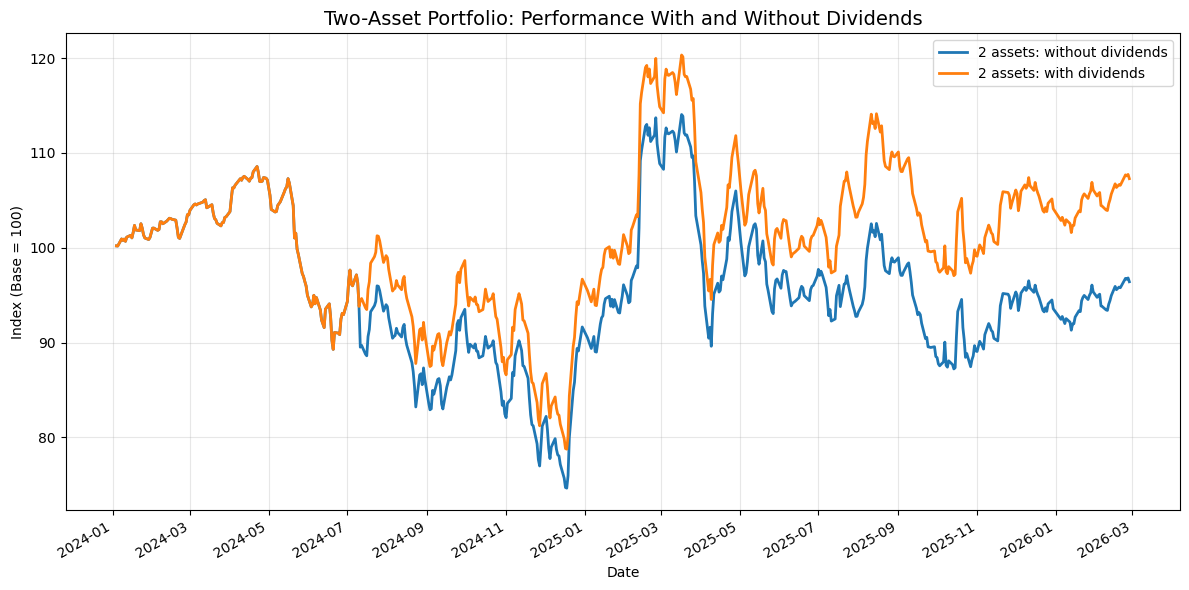

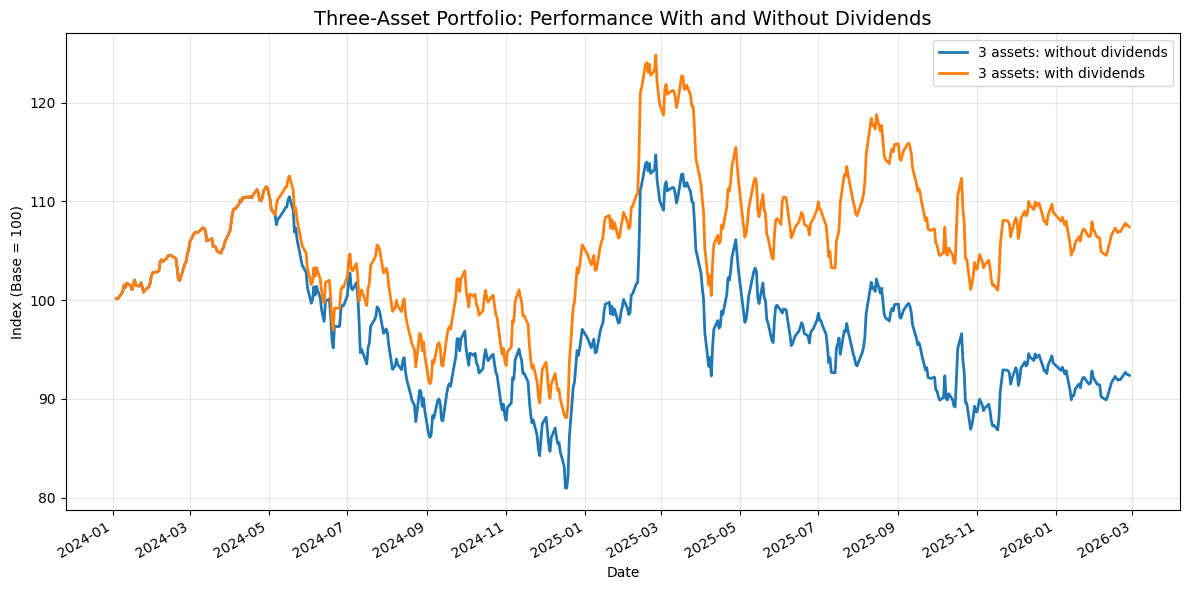

In [49]:
print("=" * 70)
print("PRICE DATA")
print("=" * 70)
print(prices.head())
print(prices.tail())

# DOWNLOAD DIVIDENDS FROM MOEX
def get_dividends(ticker: str, start_date: str, end_date: str) -> pd.DataFrame:
    """
    Download dividend data for one ticker.
    Returns a DataFrame with columns:
    - date
    - dividend
    """
    url = f"https://iss.moex.com/iss/securities/{ticker}/dividends.json?iss.meta=off"
    response = requests.get(url, timeout=30)

    if response.status_code != 200:
        print(f"Error retrieving dividends for {ticker}: {response.status_code}")
        return pd.DataFrame(columns=["date", "dividend"])

    json_data = response.json()
    dividends_block = json_data.get("dividends", {})
    columns = dividends_block.get("columns", [])
    data = dividends_block.get("data", [])

    if not data:
        return pd.DataFrame(columns=["date", "dividend"])

    div_df = pd.DataFrame(data=data, columns=columns)

    if "registryclosedate" not in div_df.columns or "value" not in div_df.columns:
        print(f"Required dividend columns not found for {ticker}")
        return pd.DataFrame(columns=["date", "dividend"])

    div_df = div_df[["registryclosedate", "value"]].copy()
    div_df["registryclosedate"] = pd.to_datetime(div_df["registryclosedate"], errors="coerce")
    div_df["value"] = pd.to_numeric(div_df["value"], errors="coerce")

    div_df = div_df[
        (div_df["registryclosedate"] >= pd.to_datetime(start_date)) &
        (div_df["registryclosedate"] <= pd.to_datetime(end_date))
    ].dropna()

    div_df = div_df.rename(columns={
        "registryclosedate": "date",
        "value": "dividend"
    })

    return div_df

# ALIGN DIVIDENDS TO TRADING DAYS
dividends_on_calendar = pd.DataFrame(index=prices.index)

for ticker in tickers:
    div_df = get_dividends(ticker, start_date, end_date)
    dividends_on_calendar[f"{ticker}_div"] = 0.0

    if not div_df.empty:
        for _, row in div_df.iterrows():
            div_date = row["date"]
            div_value = row["dividend"]

            # Move dividend to the first available trading day on or after registryclosedate
            valid_dates = prices.index[prices.index >= div_date]
            if len(valid_dates) > 0:
                dividends_on_calendar.loc[valid_dates[0], f"{ticker}_div"] += div_value

print("\n" + "=" * 70)
print("DIVIDEND DATA ALIGNED TO TRADING DAYS")
print("=" * 70)
print(dividends_on_calendar[dividends_on_calendar.sum(axis=1) > 0].head(20))

# CALCULATE RETURNS: WITHOUT DIVIDENDS AND WITH DIVIDENDS
price_returns = prices.pct_change().dropna()

total_returns = pd.DataFrame(index=prices.index, columns=tickers, dtype=float)

for ticker in tickers:
    total_returns[ticker] = (
        (prices[ticker] - prices[ticker].shift(1) + dividends_on_calendar[f"{ticker}_div"])
        / prices[ticker].shift(1)
    )

total_returns = total_returns.dropna()

# Align both return DataFrames to common dates
common_index = price_returns.index.intersection(total_returns.index)
price_returns = price_returns.loc[common_index]
total_returns = total_returns.loc[common_index]

# PORTFOLIOS
# Portfolio 1: two assets
weights_2 = np.array([0.5, 0.5])
assets_2 = ["SBER", "GAZP"]

portfolio_2_price = price_returns[assets_2] @ weights_2
portfolio_2_total = total_returns[assets_2] @ weights_2

# Portfolio 2: three assets
weights_3 = np.array([0.4, 0.3, 0.3])
assets_3 = ["SBER", "GAZP", "LKOH"]

portfolio_3_price = price_returns[assets_3] @ weights_3
portfolio_3_total = total_returns[assets_3] @ weights_3


# SUMMARY METRICS
def portfolio_summary(return_series: pd.Series, label: str) -> dict:
    cumulative_return = (1 + return_series).prod() - 1
    mean_return = return_series.mean()
    std_dev = return_series.std(ddof=1)
    annualized_return = mean_return * 252
    annualized_volatility = std_dev * np.sqrt(252)

    return {
        "Portfolio": label,
        "Cumulative return": cumulative_return,
        "Mean daily return": mean_return,
        "Daily volatility": std_dev,
        "Annualized return": annualized_return,
        "Annualized volatility": annualized_volatility,
    }

summary_table = pd.DataFrame([
    portfolio_summary(portfolio_2_price, "2 assets without dividends"),
    portfolio_summary(portfolio_2_total, "2 assets with dividends"),
    portfolio_summary(portfolio_3_price, "3 assets without dividends"),
    portfolio_summary(portfolio_3_total, "3 assets with dividends"),
])

print("\n" + "=" * 70)
print("PORTFOLIO COMPARISON")
print("=" * 70)
print(summary_table.round(6))

# DIVIDEND EFFECT
print("\n" + "=" * 70)
print("DIVIDEND EFFECT")
print("=" * 70)

effect_2 = ((1 + portfolio_2_total).prod() - 1) - ((1 + portfolio_2_price).prod() - 1)
effect_3 = ((1 + portfolio_3_total).prod() - 1) - ((1 + portfolio_3_price).prod() - 1)

print(f"Additional cumulative return from dividends (2-asset portfolio): {effect_2:.2%}")
print(f"Additional cumulative return from dividends (3-asset portfolio): {effect_3:.2%}")

# PLOT: 2-ASSET PORTFOLIO
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(cum_df.index, cum_df["Portfolio_2_Price"], label="2 assets: without dividends", linewidth=2)
ax.plot(cum_df.index, cum_df["Portfolio_2_Total"], label="2 assets: with dividends", linewidth=2)

ax.set_title("Two-Asset Portfolio: Performance With and Without Dividends", fontsize=14)
ax.set_xlabel("Date")
ax.set_ylabel("Index (Base = 100)")
ax.legend()
ax.grid(True, alpha=0.3)

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
fig.autofmt_xdate()

plt.tight_layout()
plt.show()

# PLOT: 3-ASSET PORTFOLIO
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(cum_df.index, cum_df["Portfolio_3_Price"], label="3 assets: without dividends", linewidth=2)
ax.plot(cum_df.index, cum_df["Portfolio_3_Total"], label="3 assets: with dividends", linewidth=2)

ax.set_title("Three-Asset Portfolio: Performance With and Without Dividends", fontsize=14)
ax.set_xlabel("Date")
ax.set_ylabel("Index (Base = 100)")
ax.legend()
ax.grid(True, alpha=0.3)

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
fig.autofmt_xdate()

plt.tight_layout()
plt.show()